# Task 3 — Ablation, 5-Fold Repetition CV, and Significance Test
## NinaPro DB1 Continuous Wrist-Angle Regression

This notebook is a **separate Task 3 notebook**. It does not replace the best-model notebook.

### Current proposed model

**Trajectory-Supervised Learned Dynamic GAT–TCN–LSTM**

Current measured result from the earlier notebook:

- RMSE = **0.13132955**
- MAE = **0.09264448**
- \(R^2\) = **0.69134566**

Previous strongest baseline:

- TCN–LSTM RMSE = **0.13193475**
- TCN–LSTM \(R^2\) = **0.67554838**

---

# What this notebook does

## Part A — Controlled ablation

The data protocol stays fixed:

- development train: repetitions **1–4**
- validation: repetition **5**
- repetitions **6–10 are not used for ablation selection**

Every ablation changes **one factor at a time** from the reference model.

The notebook includes the regression-appropriate versions of the requested Task 3 factors:

1. GNN layers
2. hidden size
3. dropout
4. normalization / BatchNorm
5. learning-rate schedule
6. optimizer
7. graph-construction method
8. edge-weight method
9. GNN variant: GAT / GCN / GraphSAGE
10. regression target-density weighting (regression analogue of imbalance handling)
11. early stopping
12. proposed-model component ablations:
   - trajectory supervision
   - velocity loss
   - temporal attention

## Part B — 5-fold repetition CV

After choosing/fixing one configuration, perform:

```text
Fold 1: hold out repetition 1
Fold 2: hold out repetition 2
Fold 3: hold out repetition 3
Fold 4: hold out repetition 4
Fold 5: hold out repetition 5
```

The same fold is used for TCN–LSTM and the GNN.

The CV reports:

- RMSE mean ± std
- MAE mean ± std
- \(R^2\) mean ± std
- paired t-test on fold RMSE
- Wilcoxon signed-rank test on fold RMSE

This is **repetition-based CV**, not subject-independent CV.

---

## Runtime note

The full ablation suite is computationally expensive. Use:

```python
QUICK_SMOKE_TEST = True
```

only to confirm the notebook runs.

For report-quality results use:

```python
QUICK_SMOKE_TEST = False
```

and run the required ablations.

## 1. Imports and reproducibility

In [37]:
import gc
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from dataclasses import dataclass, replace
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from scipy.io import loadmat
from scipy.stats import ttest_rel, wilcoxon
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42

def reset_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_seed()

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
Device: cuda


## 2. Dataset and experiment configuration

In [38]:
# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
FS = 100
EXERCISE = 2
SUBJECTS = tuple(range(1, 9))
N_EMG = 10
N_GLOVE = 22

OFFICIAL_URL_TEMPLATE = (
    "https://ninapro.hevs.ch/files/DB1/Preprocessed/s{subject}.zip"
)

MOVEMENTS = {
    13: "WF",
    16: "WUD",
    17: "WECH",
}

TARGET_GLOVE_COLUMN = 20

# ------------------------------------------------------------
# Repetition protocol
# ------------------------------------------------------------
DEV_TRAIN_REPETITIONS = (1, 2, 3, 4)
VAL_REPETITIONS = (5,)
CV_REPETITIONS = (1, 2, 3, 4, 5)
FINAL_TRAIN_REPETITIONS = (1, 2, 3, 4, 5)
FINAL_TEST_REPETITIONS = (6, 7, 8, 9, 10)

# ------------------------------------------------------------
# Signal preprocessing
# ------------------------------------------------------------
WINDOW_SAMPLES = 10
OVERLAP_SAMPLES = 1
WINDOW_STEP = WINDOW_SAMPLES - OVERLAP_SAMPLES

SEQUENCE_LENGTH = 20
SEQUENCE_STRIDE = 1
TARGET_AHEAD_SAMPLES = 1
PRE_MOVEMENT_REST_SAMPLES = 300

BASE_FEATURES = 20
NODE_STATS = 4
NODE_FEATURES = WINDOW_SAMPLES + NODE_STATS  # 14

# ------------------------------------------------------------
# TCN-LSTM
# ------------------------------------------------------------
TCN_CHANNELS = 25
TCN_KERNEL_SIZE = 15
TCN_DILATIONS = (1, 2, 4)
TEMPORAL_DROPOUT = 0.20

LSTM_HIDDEN_UNITS = 50
LSTM_LAYERS = 5

BACKBONE_EPOCHS = 50
BACKBONE_LR = 0.01
BACKBONE_LR_STEP = 10
BACKBONE_LR_GAMMA = 0.5

# ------------------------------------------------------------
# Ablation training budget
# Same budget for every variant.
# ------------------------------------------------------------
ABLATION_ADAPTER_EPOCHS = 25
ABLATION_FINETUNE_EPOCHS = 15
ABLATION_PATIENCE = 7

FULL_FINAL_ADAPTER_EPOCHS = 45
FULL_FINAL_FINETUNE_EPOCHS = 35

BATCH_SIZE = 32
NUM_WORKERS = 0
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
MIN_VAL_IMPROVEMENT = 1e-5

# ------------------------------------------------------------
# Run scope
# ------------------------------------------------------------
QUICK_SMOKE_TEST = False

if QUICK_SMOKE_TEST:
    RUN_SUBJECTS = (1,)
    RUN_MOVEMENTS = {17: "WECH"}

    RUN_BACKBONE_EPOCHS = 2
    RUN_ABLATION_ADAPTER_EPOCHS = 2
    RUN_ABLATION_FINETUNE_EPOCHS = 1
else:
    RUN_SUBJECTS = SUBJECTS
    RUN_MOVEMENTS = MOVEMENTS

    RUN_BACKBONE_EPOCHS = BACKBONE_EPOCHS
    RUN_ABLATION_ADAPTER_EPOCHS = ABLATION_ADAPTER_EPOCHS
    RUN_ABLATION_FINETUNE_EPOCHS = ABLATION_FINETUNE_EPOCHS

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ON_KAGGLE = Path("/kaggle").exists()

WORK_DIR = (
    Path("/kaggle/working/ninapro_db1_task3_ablation")
    if ON_KAGGLE
    else Path("./ninapro_db1_task3_ablation")
)

ZIP_DIR = WORK_DIR / "official_zips"
MAT_DIR = WORK_DIR / "mat_files"
CACHE_DIR = WORK_DIR / "raw_cache"
BACKBONE_CACHE_DIR = WORK_DIR / "backbone_cache"
ABLATION_DIR = WORK_DIR / "ablation"
CV_DIR = WORK_DIR / "cv"
FIGURE_DIR = WORK_DIR / "figures"

for directory in [
    WORK_DIR,
    ZIP_DIR,
    MAT_DIR,
    CACHE_DIR,
    BACKBONE_CACHE_DIR,
    ABLATION_DIR,
    CV_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Quick smoke test:", QUICK_SMOKE_TEST)
print("Subjects:", RUN_SUBJECTS)
print("Movements:", RUN_MOVEMENTS)

Quick smoke test: False
Subjects: (1, 2, 3, 4, 5, 6, 7, 8)
Movements: {13: 'WF', 16: 'WUD', 17: 'WECH'}


## 3. Download official NinaPro DB1

In [39]:
def valid_zip(path):
    if not path.exists() or path.stat().st_size == 0:
        return False

    try:
        if not zipfile.is_zipfile(path):
            return False

        with zipfile.ZipFile(path, "r") as archive:
            return archive.testzip() is None

    except Exception:
        return False


def download_subject(subject):
    url = OFFICIAL_URL_TEMPLATE.format(subject=subject)
    zip_path = ZIP_DIR / f"s{subject}.zip"
    partial_path = ZIP_DIR / f"s{subject}.zip.part"

    if valid_zip(zip_path):
        return zip_path

    headers = {"User-Agent": "Mozilla/5.0 NinaPro-DynamicGAT"}
    existing = partial_path.stat().st_size if partial_path.exists() else 0

    if existing:
        headers["Range"] = f"bytes={existing}-"

    response = requests.get(
        url,
        stream=True,
        timeout=(30, 180),
        headers=headers,
    )

    if response.status_code not in (200, 206):
        raise RuntimeError(f"HTTP {response.status_code}: {url}")

    if existing and response.status_code == 200:
        existing = 0
        partial_path.unlink(missing_ok=True)

    total = (
        existing + int(response.headers.get("content-length", 0))
        if response.headers.get("content-length")
        else None
    )

    with open(partial_path, "ab" if existing else "wb") as file, tqdm(
        total=total,
        initial=existing,
        unit="B",
        unit_scale=True,
        desc=f"Subject {subject}",
    ) as progress:
        for chunk in response.iter_content(1024 * 1024):
            if chunk:
                file.write(chunk)
                progress.update(len(chunk))

    partial_path.replace(zip_path)

    if not valid_zip(zip_path):
        raise RuntimeError(f"ZIP validation failed for subject {subject}")

    return zip_path


def extract_subject(subject, zip_path):
    subject_dir = MAT_DIR / f"s{subject:02d}"
    marker = subject_dir / ".complete"

    if marker.exists() and list(subject_dir.rglob("*.mat")):
        return subject_dir

    if subject_dir.exists():
        shutil.rmtree(subject_dir)

    subject_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(subject_dir)

    marker.write_text("ok")
    return subject_dir


for subject in RUN_SUBJECTS:
    folder = extract_subject(subject, download_subject(subject))
    print(
        f"Subject {subject}:",
        len(list(folder.rglob("*.mat"))),
        "MAT files",
    )

Subject 1: 3 MAT files
Subject 2: 3 MAT files
Subject 3: 3 MAT files
Subject 4: 3 MAT files
Subject 5: 3 MAT files
Subject 6: 3 MAT files
Subject 7: 3 MAT files
Subject 8: 3 MAT files


## 4. MATLAB loading and trial extraction

In [40]:
def orient_matrix(array, columns, name):
    array = np.asarray(array).squeeze()

    if array.ndim != 2:
        raise ValueError(f"{name} must be 2-D")

    if array.shape[1] == columns:
        return array

    if array.shape[0] == columns:
        return array.T

    raise ValueError(f"{name} shape {array.shape}")


def load_hdf5_mat(path):
    output = {}

    with h5py.File(path, "r") as file:
        for key in file.keys():
            value = np.array(file[key])
            output[key.lower()] = value.T if value.ndim == 2 else value

    return output


def load_mat(path):
    try:
        raw = loadmat(
            path,
            squeeze_me=True,
            struct_as_record=False,
        )

        return {
            key.lower(): value
            for key, value in raw.items()
            if not key.startswith("__")
        }

    except NotImplementedError:
        return load_hdf5_mat(path)


def scalar_int(value):
    return int(np.asarray(value).squeeze().item())


def find_exercise_file(subject):
    matches = []

    for path in sorted((MAT_DIR / f"s{subject:02d}").rglob("*.mat")):
        try:
            record = load_mat(path)

            if (
                "exercise" in record
                and scalar_int(record["exercise"]) == EXERCISE
            ):
                matches.append(path)

        except Exception:
            pass

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one Exercise-2 file for S{subject}, got {matches}"
        )

    return matches[0]


def load_exercise2(subject):
    path = find_exercise_file(subject)
    record = load_mat(path)

    return {
        "subject": subject,
        "emg": orient_matrix(
            record["emg"],
            N_EMG,
            "emg",
        ).astype(np.float32),
        "glove": orient_matrix(
            record["glove"],
            N_GLOVE,
            "glove",
        ).astype(np.float32),
        "restimulus": np.asarray(
            record["restimulus"]
        ).reshape(-1).astype(np.int16),
        "rerepetition": np.asarray(
            record["rerepetition"]
        ).reshape(-1).astype(np.int16),
    }


@dataclass
class MovementTrial:
    subject: int
    movement: int
    repetition: int
    start: int
    movement_start: int
    end: int


def contiguous_segments(mask):
    change = np.diff(
        np.asarray(mask, dtype=np.int8),
        prepend=0,
        append=0,
    )

    return list(
        zip(
            np.flatnonzero(change == 1),
            np.flatnonzero(change == -1),
        )
    )


def find_movement_trials(record, movement):
    trials = []

    for repetition in range(1, 11):
        mask = (
            (record["restimulus"] == movement)
            & (record["rerepetition"] == repetition)
        )

        segments = contiguous_segments(mask)

        if len(segments) != 1:
            raise RuntimeError(
                f'S{record["subject"]} M{movement} R{repetition}: '
                f"expected 1 segment, got {len(segments)}"
            )

        movement_start, movement_end = segments[0]

        begin = max(
            0,
            movement_start - PRE_MOVEMENT_REST_SAMPLES,
        )

        while (
            begin < movement_start
            and record["restimulus"][begin] != 0
        ):
            begin += 1

        trials.append(
            MovementTrial(
                subject=record["subject"],
                movement=movement,
                repetition=repetition,
                start=begin,
                movement_start=movement_start,
                end=movement_end,
            )
        )

    return trials

## 5. Frame features and 20-frame trajectory targets

In [41]:
def extract_base_features(window):
    mav = np.mean(np.abs(window), axis=0)

    rms = np.sqrt(
        np.mean(window ** 2, axis=0)
        + 1e-12
    )

    return np.concatenate(
        [mav, rms]
    ).astype(np.float32)


def extract_node_features(window):
    # window: [10 time samples, 10 electrodes]
    raw = window.T  # [10 electrodes, 10 raw samples]

    mav = np.mean(np.abs(window), axis=0)

    rms = np.sqrt(
        np.mean(window ** 2, axis=0)
        + 1e-12
    )

    waveform_length = np.sum(
        np.abs(np.diff(window, axis=0)),
        axis=0,
    )

    variance = np.var(window, axis=0)

    statistics = np.stack(
        [mav, rms, waveform_length, variance],
        axis=-1,
    )

    return np.concatenate(
        [raw, statistics],
        axis=-1,
    ).astype(np.float32)


def build_trial_frames(record, trial):
    base_frames = []
    node_frames = []
    targets = []
    indices = []

    first_end = trial.start + WINDOW_SAMPLES - 1
    last_end = trial.end - 1 - TARGET_AHEAD_SAMPLES

    for window_end in range(
        first_end,
        last_end + 1,
        WINDOW_STEP,
    ):
        window_start = window_end - WINDOW_SAMPLES + 1
        target_index = window_end + TARGET_AHEAD_SAMPLES

        window = record["emg"][
            window_start:
            window_end + 1
        ]

        base_frames.append(
            extract_base_features(window)
        )

        node_frames.append(
            extract_node_features(window)
        )

        targets.append(
            record["glove"][
                target_index,
                TARGET_GLOVE_COLUMN,
            ]
        )

        indices.append(target_index)

    return (
        np.asarray(base_frames, dtype=np.float32),
        np.asarray(node_frames, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(indices, dtype=np.int32),
    )


def make_sequences(base, nodes, targets, indices):
    """
    Returns:
        B_seq:   [samples, 20, 20]
        N_seq:   [samples, 20, 10, 14]
        y_final: [samples, 1]
        y_seq:   [samples, 20, 1]
        idx:     [samples]
    """
    sequence_base = []
    sequence_nodes = []
    final_targets = []
    sequence_targets = []
    sequence_indices = []

    for start in range(
        0,
        len(base) - SEQUENCE_LENGTH + 1,
        SEQUENCE_STRIDE,
    ):
        end = start + SEQUENCE_LENGTH

        sequence_base.append(base[start:end])
        sequence_nodes.append(nodes[start:end])

        target_sequence = targets[start:end]

        sequence_targets.append(
            target_sequence.reshape(
                SEQUENCE_LENGTH,
                1,
            )
        )

        final_targets.append(
            target_sequence[-1]
        )

        sequence_indices.append(
            indices[end - 1]
        )

    return (
        np.asarray(sequence_base, dtype=np.float32),
        np.asarray(sequence_nodes, dtype=np.float32),
        np.asarray(final_targets, dtype=np.float32).reshape(-1, 1),
        np.asarray(sequence_targets, dtype=np.float32),
        np.asarray(sequence_indices, dtype=np.int32),
    )

## 6. Build/cache repetition data and scale without leakage

In [42]:
def raw_cache_path(subject, movement):
    return (
        CACHE_DIR
        / f"s{subject:02d}_m{movement:02d}_trajectory_raw_v2.npz"
    )


def build_all_raw(subject, movement, force=False):
    cache_path = raw_cache_path(subject, movement)

    if cache_path.exists() and not force:
        with np.load(cache_path) as cache:
            required = {
                "B_raw",
                "N_raw",
                "y_raw",
                "y_seq_raw",
                "idx",
                "rep",
            }

            if required.issubset(set(cache.files)):
                return {
                    key: cache[key]
                    for key in cache.files
                }

    record = load_exercise2(subject)

    all_base = []
    all_nodes = []
    all_targets = []
    all_sequence_targets = []
    all_indices = []
    all_repetitions = []

    for trial in find_movement_trials(record, movement):
        base, nodes, targets, indices = build_trial_frames(
            record,
            trial,
        )

        (
            base,
            nodes,
            final_targets,
            sequence_targets,
            indices,
        ) = make_sequences(
            base,
            nodes,
            targets,
            indices,
        )

        all_base.append(base)
        all_nodes.append(nodes)
        all_targets.append(final_targets)
        all_sequence_targets.append(sequence_targets)
        all_indices.append(indices)

        all_repetitions.append(
            np.full(
                len(final_targets),
                trial.repetition,
                dtype=np.int16,
            )
        )

    output = {
        "B_raw": np.concatenate(all_base),
        "N_raw": np.concatenate(all_nodes),
        "y_raw": np.concatenate(all_targets),
        "y_seq_raw": np.concatenate(all_sequence_targets),
        "idx": np.concatenate(all_indices),
        "rep": np.concatenate(all_repetitions),
    }

    np.savez_compressed(
        cache_path,
        **output,
    )

    return output


def make_scaled_split(
    raw,
    train_repetitions,
    validation_repetitions=(),
    test_repetitions=(),
):
    train_mask = np.isin(
        raw["rep"],
        train_repetitions,
    )

    validation_mask = (
        np.isin(
            raw["rep"],
            validation_repetitions,
        )
        if len(validation_repetitions)
        else np.zeros(len(raw["rep"]), dtype=bool)
    )

    test_mask = (
        np.isin(
            raw["rep"],
            test_repetitions,
        )
        if len(test_repetitions)
        else np.zeros(len(raw["rep"]), dtype=bool)
    )

    if train_mask.sum() == 0:
        raise RuntimeError("Training split is empty.")

    base_scaler = StandardScaler().fit(
        raw["B_raw"][train_mask].reshape(
            -1,
            BASE_FEATURES,
        )
    )

    node_scaler = StandardScaler().fit(
        raw["N_raw"][train_mask].reshape(
            -1,
            N_EMG * NODE_FEATURES,
        )
    )

    # Keep target scaling compatible with the previous baseline:
    # fit min/max on the final targets of the training repetitions.
    train_target_raw = raw["y_raw"][train_mask]

    target_min = float(train_target_raw.min())
    target_max = float(train_target_raw.max())

    target_range = max(
        target_max - target_min,
        1e-8,
    )

    def scale_base(values):
        shape = values.shape

        return base_scaler.transform(
            values.reshape(
                -1,
                BASE_FEATURES,
            )
        ).reshape(shape).astype(np.float32)

    def scale_nodes(values):
        shape = values.shape

        return node_scaler.transform(
            values.reshape(
                -1,
                N_EMG * NODE_FEATURES,
            )
        ).reshape(shape).astype(np.float32)

    def scale_target(values):
        return (
            (values - target_min)
            / target_range
        ).astype(np.float32)

    output = {
        "B_train": scale_base(raw["B_raw"][train_mask]),
        "N_train": scale_nodes(raw["N_raw"][train_mask]),
        "y_train": scale_target(raw["y_raw"][train_mask]),
        "y_seq_train": scale_target(raw["y_seq_raw"][train_mask]),
        "rep_train": raw["rep"][train_mask],
        "idx_train": raw["idx"][train_mask],
        "target_min": target_min,
        "target_max": target_max,
    }

    if validation_mask.any():
        output.update(
            {
                "B_val": scale_base(raw["B_raw"][validation_mask]),
                "N_val": scale_nodes(raw["N_raw"][validation_mask]),
                "y_val": scale_target(raw["y_raw"][validation_mask]),
                "y_seq_val": scale_target(raw["y_seq_raw"][validation_mask]),
                "rep_val": raw["rep"][validation_mask],
                "idx_val": raw["idx"][validation_mask],
            }
        )

    if test_mask.any():
        output.update(
            {
                "B_test": scale_base(raw["B_raw"][test_mask]),
                "N_test": scale_nodes(raw["N_raw"][test_mask]),
                "y_test": scale_target(raw["y_raw"][test_mask]),
                "y_seq_test": scale_target(raw["y_seq_raw"][test_mask]),
                "rep_test": raw["rep"][test_mask],
                "idx_test": raw["idx"][test_mask],
            }
        )

    return output


example_raw = build_all_raw(
    RUN_SUBJECTS[0],
    next(iter(RUN_MOVEMENTS)),
)

example_split = make_scaled_split(
    example_raw,
    DEV_TRAIN_REPETITIONS,
    VAL_REPETITIONS,
    FINAL_TEST_REPETITIONS,
)

print("Train base:", example_split["B_train"].shape)
print("Train graph:", example_split["N_train"].shape)
print("Train final target:", example_split["y_train"].shape)
print("Train sequence target:", example_split["y_seq_train"].shape)
print("Validation:", example_split["B_val"].shape)
print("Test:", example_split["B_test"].shape)

Train base: (216, 20, 20)
Train graph: (216, 20, 10, 14)
Train final target: (216, 1)
Train sequence target: (216, 20, 1)
Validation: (45, 20, 20)
Test: (221, 20, 20)


## 7. TCN–LSTM baseline / warm-start backbone

In [43]:
class Chomp1d(nn.Module):
    def __init__(self, amount):
        super().__init__()
        self.amount = amount

    def forward(self, x):
        if self.amount == 0:
            return x

        return x[:, :, :-self.amount].contiguous()


class TemporalBlock(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        kernel_size,
        dilation,
        dropout,
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.network = nn.Sequential(
            weight_norm(
                nn.Conv1d(
                    input_channels,
                    output_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            weight_norm(
                nn.Conv1d(
                    output_channels,
                    output_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = (
            nn.Conv1d(
                input_channels,
                output_channels,
                1,
            )
            if input_channels != output_channels
            else None
        )

        self.activation = nn.ReLU()

    def forward(self, x):
        residual = (
            x
            if self.downsample is None
            else self.downsample(x)
        )

        return self.activation(
            self.network(x)
            + residual
        )


class TCNEncoder(nn.Module):
    def __init__(self, input_features=BASE_FEATURES):
        super().__init__()

        blocks = []
        channels = input_features

        for dilation in TCN_DILATIONS:
            blocks.append(
                TemporalBlock(
                    channels,
                    TCN_CHANNELS,
                    TCN_KERNEL_SIZE,
                    dilation,
                    TEMPORAL_DROPOUT,
                )
            )

            channels = TCN_CHANNELS

        self.network = nn.Sequential(*blocks)

    def forward(self, x):
        return self.network(
            x.transpose(1, 2)
        ).transpose(1, 2)


class TCNLSTMBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.tcn = TCNEncoder(BASE_FEATURES)

        self.lstm = nn.LSTM(
            input_size=BASE_FEATURES + TCN_CHANNELS,
            hidden_size=LSTM_HIDDEN_UNITS,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=TEMPORAL_DROPOUT,
        )

        self.output = nn.Linear(
            LSTM_HIDDEN_UNITS,
            1,
        )

    def forward(self, base):
        tcn_features = self.tcn(base)

        temporal = torch.cat(
            [base, tcn_features],
            dim=-1,
        )

        sequence_output, _ = self.lstm(temporal)

        return self.output(
            sequence_output[:, -1, :]
        )

## 8. Flexible graph configuration

The reference configuration is your current best architecture.

Each ablation below changes **only one field** from the reference.

### Graph-construction modes

- `learned_dynamic`: input-dependent adjacency + learned global electrode bias.
- `learned_global`: one learned static adjacency shared by all windows.
- `cosine_topk`: top-k graph from absolute cosine similarity of raw electrode windows.

### Edge weighting

For `cosine_topk`:
- `cosine`: retain actual cosine strengths.
- `binary`: all retained edges have weight 1.

### GNN variants

- `gat`
- `gcn`
- `graphsage`

In [44]:
@dataclass(frozen=True)
class ModelConfig:
    name: str = "reference"

    # Graph architecture
    gnn_variant: str = "gat"  # gat / gcn / graphsage
    graph_mode: str = "learned_dynamic"  # learned_dynamic / learned_global / cosine_topk
    edge_weight_mode: str = "learned"  # learned / cosine / binary

    graph_layers: int = 2
    graph_hidden: int = 32
    graph_heads: int = 4
    graph_frame_dim: int = 32
    graph_dropout: float = 0.10
    graph_topk: int = 3

    electrode_embed_dim: int = 8
    normalization: str = "layer"  # layer / batch / none

    # Proposed trajectory components
    sequence_loss_weight: float = 0.25
    velocity_loss_weight: float = 0.05
    temporal_attention: bool = True
    temporal_attention_dim: int = 32
    temporal_attention_dropout: float = 0.10

    # Optimisation
    optimizer_name: str = "adamw"  # adamw / adam
    scheduler_name: str = "plateau"  # plateau / cosine / none

    graph_lr: float = 5e-4
    fusion_lr: float = 3e-4
    attention_lr: float = 3e-4

    finetune_graph_lr: float = 2e-4
    finetune_fusion_lr: float = 1e-4
    finetune_attention_lr: float = 1e-4
    finetune_lstm_lr: float = 1e-5
    finetune_tcn_lr: float = 5e-6

    early_stopping: bool = True

    # Regression analogue of imbalance handling
    target_density_weighting: bool = False


REFERENCE_CONFIG = ModelConfig()

print(REFERENCE_CONFIG)

ModelConfig(name='reference', gnn_variant='gat', graph_mode='learned_dynamic', edge_weight_mode='learned', graph_layers=2, graph_hidden=32, graph_heads=4, graph_frame_dim=32, graph_dropout=0.1, graph_topk=3, electrode_embed_dim=8, normalization='layer', sequence_loss_weight=0.25, velocity_loss_weight=0.05, temporal_attention=True, temporal_attention_dim=32, temporal_attention_dropout=0.1, optimizer_name='adamw', scheduler_name='plateau', graph_lr=0.0005, fusion_lr=0.0003, attention_lr=0.0003, finetune_graph_lr=0.0002, finetune_fusion_lr=0.0001, finetune_attention_lr=0.0001, finetune_lstm_lr=1e-05, finetune_tcn_lr=5e-06, early_stopping=True, target_density_weighting=False)


## 9. Normalization helper

In [45]:
class GraphNorm(nn.Module):
    def __init__(
        self,
        hidden_dim,
        mode="layer",
    ):
        super().__init__()

        self.mode = mode

        if mode == "layer":
            self.norm = nn.LayerNorm(
                hidden_dim
            )

        elif mode == "batch":
            self.norm = nn.BatchNorm1d(
                hidden_dim
            )

        elif mode == "none":
            self.norm = nn.Identity()

        else:
            raise ValueError(
                f"Unknown normalization: {mode}"
            )

    def forward(self, x):
        # x: [BT, N, H]
        if self.mode == "batch":
            shape = x.shape

            x = self.norm(
                x.reshape(
                    -1,
                    shape[-1],
                )
            )

            return x.reshape(shape)

        return self.norm(x)

## 10. Flexible graph constructor

In [46]:
class GraphConstructor(nn.Module):
    def __init__(
        self,
        hidden_dim,
        heads,
        graph_mode,
        edge_weight_mode,
        topk,
    ):
        super().__init__()

        if hidden_dim % heads != 0:
            raise ValueError(
                "graph_hidden must be divisible by graph_heads"
            )

        self.hidden_dim = hidden_dim
        self.heads = heads
        self.head_dim = hidden_dim // heads

        self.graph_mode = graph_mode
        self.edge_weight_mode = edge_weight_mode
        self.topk = topk

        self.query = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.key = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.global_bias = nn.Parameter(
            torch.zeros(
                heads,
                N_EMG,
                N_EMG,
            )
        )

        nn.init.normal_(
            self.global_bias,
            mean=0.0,
            std=0.10,
        )

    def _dynamic_logits(self, x):
        bt, n_nodes, _ = x.shape

        q = self.query(x).view(
            bt,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        k = self.key(x).view(
            bt,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        logits = torch.matmul(
            q,
            k.transpose(-1, -2),
        ) / math.sqrt(
            self.head_dim
        )

        return logits

    def _cosine_graph(
        self,
        raw_nodes,
    ):
        # raw_nodes: [BT, N, NODE_FEATURES]
        raw = raw_nodes[
            ...,
            :WINDOW_SAMPLES,
        ]

        raw = F.normalize(
            raw,
            p=2,
            dim=-1,
            eps=1e-8,
        )

        similarity = torch.abs(
            torch.matmul(
                raw,
                raw.transpose(
                    -1,
                    -2,
                ),
            )
        )

        bt, n_nodes, _ = similarity.shape

        identity = torch.eye(
            n_nodes,
            device=similarity.device,
            dtype=torch.bool,
        ).unsqueeze(0)

        candidate = similarity.masked_fill(
            identity,
            -1.0,
        )

        k = min(
            self.topk,
            n_nodes - 1,
        )

        top_indices = torch.topk(
            candidate,
            k=k,
            dim=-1,
        ).indices

        mask = torch.zeros_like(
            similarity,
            dtype=torch.bool,
        )

        mask.scatter_(
            -1,
            top_indices,
            True,
        )

        # Symmetric union + self loops
        mask = (
            mask
            | mask.transpose(-1, -2)
            | identity
        )

        if self.edge_weight_mode == "binary":
            adjacency = mask.float()

        elif self.edge_weight_mode == "cosine":
            adjacency = (
                similarity
                * mask.float()
            )

            adjacency = adjacency + (
                identity.float()
                * 1e-6
            )

        else:
            raise ValueError(
                "cosine_topk requires "
                "edge_weight_mode='binary' or 'cosine'"
            )

        adjacency = adjacency / (
            adjacency.sum(
                dim=-1,
                keepdim=True,
            )
            + 1e-8
        )

        # GAT prior with one identical copy per head.
        head_adjacency = adjacency.unsqueeze(
            1
        ).expand(
            -1,
            self.heads,
            -1,
            -1,
        )

        return adjacency, head_adjacency

    def forward(
        self,
        x,
        raw_nodes,
    ):
        """
        Returns
        -------
        adjacency:
            [BT, N, N] row-normalized, used by GCN/SAGE.
        head_adjacency:
            [BT, heads, N, N], used as a GAT prior.
        """

        if self.graph_mode == "learned_dynamic":
            logits = (
                self._dynamic_logits(x)
                + self.global_bias.unsqueeze(0)
            )

            head_adjacency = torch.softmax(
                logits,
                dim=-1,
            )

        elif self.graph_mode == "learned_global":
            bt = x.shape[0]

            head_adjacency = torch.softmax(
                self.global_bias.unsqueeze(0)
                .expand(
                    bt,
                    -1,
                    -1,
                    -1,
                ),
                dim=-1,
            )

        elif self.graph_mode == "cosine_topk":
            return self._cosine_graph(
                raw_nodes
            )

        else:
            raise ValueError(
                f"Unknown graph_mode: {self.graph_mode}"
            )

        adjacency = head_adjacency.mean(
            dim=1
        )

        adjacency = adjacency / (
            adjacency.sum(
                dim=-1,
                keepdim=True,
            )
            + 1e-8
        )

        return (
            adjacency,
            head_adjacency,
        )

## 11. Flexible GAT / GCN / GraphSAGE layers

In [47]:
class GATGraphLayer(nn.Module):
    def __init__(
        self,
        hidden_dim,
        heads,
        dropout,
        normalization,
    ):
        super().__init__()

        if hidden_dim % heads != 0:
            raise ValueError(
                "hidden_dim must be divisible by heads"
            )

        self.hidden_dim = hidden_dim
        self.heads = heads
        self.head_dim = hidden_dim // heads

        self.query = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.key = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.value = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.out = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.norm1 = GraphNorm(
            hidden_dim,
            normalization,
        )

        self.norm2 = GraphNorm(
            hidden_dim,
            normalization,
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                hidden_dim,
                2 * hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                2 * hidden_dim,
                hidden_dim,
            ),
        )

    def forward(
        self,
        x,
        adjacency,
        head_adjacency,
    ):
        bt, n_nodes, _ = x.shape

        q = self.query(x).view(
            bt,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        k = self.key(x).view(
            bt,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        v = self.value(x).view(
            bt,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        logits = torch.matmul(
            q,
            k.transpose(-1, -2),
        ) / math.sqrt(
            self.head_dim
        )

        # Use graph construction as a prior.
        logits = (
            logits
            + torch.log(
                head_adjacency
                + 1e-8
            )
        )

        weights = torch.softmax(
            logits,
            dim=-1,
        )

        weights = self.dropout(
            weights
        )

        message = torch.matmul(
            weights,
            v,
        )

        message = message.transpose(
            1,
            2,
        ).contiguous().view(
            bt,
            n_nodes,
            self.hidden_dim,
        )

        x = self.norm1(
            x
            + self.dropout(
                self.out(message)
            )
        )

        x = self.norm2(
            x
            + self.dropout(
                self.ffn(x)
            )
        )

        return x


class GCNGraphLayer(nn.Module):
    def __init__(
        self,
        hidden_dim,
        dropout,
        normalization,
    ):
        super().__init__()

        self.linear = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.norm = GraphNorm(
            hidden_dim,
            normalization,
        )

    def forward(
        self,
        x,
        adjacency,
        head_adjacency,
    ):
        # Symmetric-style normalization for soft adjacency.
        a = 0.5 * (
            adjacency
            + adjacency.transpose(
                -1,
                -2,
            )
        )

        degree = a.sum(
            dim=-1
        )

        inv_sqrt = torch.rsqrt(
            degree + 1e-8
        )

        normalized = (
            inv_sqrt.unsqueeze(-1)
            * a
            * inv_sqrt.unsqueeze(-2)
        )

        message = torch.matmul(
            normalized,
            x,
        )

        update = self.linear(
            message
        )

        return self.norm(
            x
            + self.dropout(
                F.gelu(update)
            )
        )


class GraphSAGELayer(nn.Module):
    def __init__(
        self,
        hidden_dim,
        dropout,
        normalization,
    ):
        super().__init__()

        self.linear = nn.Linear(
            2 * hidden_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.norm = GraphNorm(
            hidden_dim,
            normalization,
        )

    def forward(
        self,
        x,
        adjacency,
        head_adjacency,
    ):
        neighbor = torch.matmul(
            adjacency,
            x,
        )

        update = self.linear(
            torch.cat(
                [x, neighbor],
                dim=-1,
            )
        )

        return self.norm(
            x
            + self.dropout(
                F.gelu(update)
            )
        )

## 12. Flexible graph encoder

In [48]:
class FlexibleGraphEncoder(nn.Module):
    def __init__(
        self,
        cfg: ModelConfig,
    ):
        super().__init__()

        self.cfg = cfg

        self.electrode_embedding = (
            nn.Embedding(
                N_EMG,
                cfg.electrode_embed_dim,
            )
        )

        self.input_projection = nn.Linear(
            NODE_FEATURES
            + cfg.electrode_embed_dim,
            cfg.graph_hidden,
        )

        self.constructor = GraphConstructor(
            hidden_dim=cfg.graph_hidden,
            heads=cfg.graph_heads,
            graph_mode=cfg.graph_mode,
            edge_weight_mode=cfg.edge_weight_mode,
            topk=cfg.graph_topk,
        )

        layers = []

        for _ in range(
            cfg.graph_layers
        ):
            if cfg.gnn_variant == "gat":
                layer = GATGraphLayer(
                    hidden_dim=cfg.graph_hidden,
                    heads=cfg.graph_heads,
                    dropout=cfg.graph_dropout,
                    normalization=cfg.normalization,
                )

            elif cfg.gnn_variant == "gcn":
                layer = GCNGraphLayer(
                    hidden_dim=cfg.graph_hidden,
                    dropout=cfg.graph_dropout,
                    normalization=cfg.normalization,
                )

            elif cfg.gnn_variant == "graphsage":
                layer = GraphSAGELayer(
                    hidden_dim=cfg.graph_hidden,
                    dropout=cfg.graph_dropout,
                    normalization=cfg.normalization,
                )

            else:
                raise ValueError(
                    f"Unknown gnn_variant: {cfg.gnn_variant}"
                )

            layers.append(layer)

        self.layers = nn.ModuleList(
            layers
        )

        self.frame_readout = nn.Sequential(
            nn.Flatten(
                start_dim=2
            ),
            nn.Linear(
                N_EMG
                * cfg.graph_hidden,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                cfg.graph_dropout
            ),
            nn.Linear(
                128,
                cfg.graph_frame_dim,
            ),
            nn.LayerNorm(
                cfg.graph_frame_dim
            ),
        )

    def forward(
        self,
        nodes,
        return_adjacency=False,
    ):
        (
            batch_size,
            time_steps,
            n_nodes,
            _,
        ) = nodes.shape

        electrode_ids = torch.arange(
            n_nodes,
            device=nodes.device,
        )

        embedding = (
            self.electrode_embedding(
                electrode_ids
            )
            .view(
                1,
                1,
                n_nodes,
                self.cfg.electrode_embed_dim,
            )
            .expand(
                batch_size,
                time_steps,
                -1,
                -1,
            )
        )

        raw_nodes = nodes.reshape(
            batch_size
            * time_steps,
            n_nodes,
            NODE_FEATURES,
        )

        x = torch.cat(
            [
                nodes,
                embedding,
            ],
            dim=-1,
        )

        x = self.input_projection(
            x
        ).reshape(
            batch_size
            * time_steps,
            n_nodes,
            self.cfg.graph_hidden,
        )

        adjacency, head_adjacency = (
            self.constructor(
                x,
                raw_nodes,
            )
        )

        for layer in self.layers:
            x = layer(
                x,
                adjacency,
                head_adjacency,
            )

        x = x.reshape(
            batch_size,
            time_steps,
            n_nodes,
            self.cfg.graph_hidden,
        )

        graph_frame = (
            self.frame_readout(x)
        )

        if return_adjacency:
            return (
                graph_frame,
                head_adjacency.reshape(
                    batch_size,
                    time_steps,
                    self.cfg.graph_heads,
                    n_nodes,
                    n_nodes,
                ),
            )

        return graph_frame

## 13. Flexible proposed regression model

In [49]:
TEMPORAL_FEATURES = (
    BASE_FEATURES
    + TCN_CHANNELS
)


class AblationGATTCNLSTM(nn.Module):
    def __init__(
        self,
        cfg: ModelConfig,
    ):
        super().__init__()

        self.cfg = cfg

        self.tcn = TCNEncoder(
            BASE_FEATURES
        )

        self.graph = FlexibleGraphEncoder(
            cfg
        )

        self.graph_projection = (
            nn.Sequential(
                nn.Linear(
                    cfg.graph_frame_dim,
                    TEMPORAL_FEATURES,
                ),
                nn.Tanh(),
            )
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(
                TEMPORAL_FEATURES
                + cfg.graph_frame_dim,
                TEMPORAL_FEATURES,
            ),
            nn.Sigmoid(),
        )

        self.fusion_alpha = nn.Parameter(
            torch.tensor(0.0)
        )

        self.lstm = nn.LSTM(
            input_size=TEMPORAL_FEATURES,
            hidden_size=LSTM_HIDDEN_UNITS,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=TEMPORAL_DROPOUT,
        )

        self.output = nn.Linear(
            LSTM_HIDDEN_UNITS,
            1,
        )

        self.temporal_query = nn.Linear(
            LSTM_HIDDEN_UNITS,
            cfg.temporal_attention_dim,
            bias=False,
        )

        self.temporal_key = nn.Linear(
            LSTM_HIDDEN_UNITS,
            cfg.temporal_attention_dim,
            bias=False,
        )

        self.temporal_residual = nn.Sequential(
            nn.Linear(
                LSTM_HIDDEN_UNITS,
                32,
            ),
            nn.GELU(),
            nn.Dropout(
                cfg.temporal_attention_dropout
            ),
            nn.Linear(
                32,
                1,
                bias=False,
            ),
        )

        self.temporal_alpha = nn.Parameter(
            torch.tensor(0.0)
        )

    def forward(
        self,
        base,
        nodes,
        return_aux=False,
        return_adjacency=False,
    ):
        tcn_features = self.tcn(
            base
        )

        temporal = torch.cat(
            [
                base,
                tcn_features,
            ],
            dim=-1,
        )

        if return_adjacency:
            (
                graph_features,
                graph_adjacency,
            ) = self.graph(
                nodes,
                return_adjacency=True,
            )
        else:
            graph_features = self.graph(
                nodes
            )

        graph_delta = (
            self.graph_projection(
                graph_features
            )
        )

        gate = self.fusion_gate(
            torch.cat(
                [
                    temporal,
                    graph_features,
                ],
                dim=-1,
            )
        )

        fusion_scale = torch.tanh(
            self.fusion_alpha
        )

        fused = (
            temporal
            + fusion_scale
            * gate
            * graph_delta
        )

        sequence_output, _ = self.lstm(
            fused
        )

        sequence_prediction = (
            self.output(
                sequence_output
            )
        )

        base_final = (
            sequence_prediction[
                :,
                -1,
                :,
            ]
        )

        temporal_weights = None

        if self.cfg.temporal_attention:
            query = self.temporal_query(
                sequence_output[
                    :,
                    -1,
                    :,
                ]
            ).unsqueeze(1)

            keys = self.temporal_key(
                sequence_output
            )

            logits = (
                query
                * keys
            ).sum(
                dim=-1
            ) / math.sqrt(
                self.cfg.temporal_attention_dim
            )

            temporal_weights = (
                torch.softmax(
                    logits,
                    dim=-1,
                )
            )

            context = torch.sum(
                temporal_weights.unsqueeze(
                    -1
                )
                * sequence_output,
                dim=1,
            )

            temporal_delta = (
                self.temporal_residual(
                    context
                )
            )

            temporal_scale = torch.tanh(
                self.temporal_alpha
            )

            prediction = (
                base_final
                + temporal_scale
                * temporal_delta
            )

        else:
            temporal_scale = torch.zeros(
                (),
                device=base.device,
            )

            prediction = base_final

        if return_aux or return_adjacency:
            output = {
                "prediction": prediction,
                "sequence_prediction": (
                    sequence_prediction
                ),
                "temporal_weights": (
                    temporal_weights
                ),
                "fusion_scale": (
                    fusion_scale
                ),
                "temporal_scale": (
                    temporal_scale
                ),
                "gate": gate,
            }

            if return_adjacency:
                output[
                    "graph_adjacency"
                ] = graph_adjacency

            return output

        return prediction


def warm_start_from_backbone(
    model,
    backbone,
):
    model.tcn.load_state_dict(
        backbone.tcn.state_dict()
    )

    model.lstm.load_state_dict(
        backbone.lstm.state_dict()
    )

    model.output.load_state_dict(
        backbone.output.state_dict()
    )

    with torch.no_grad():
        model.fusion_alpha.zero_()
        model.temporal_alpha.zero_()

    return model

## 14. Smoke test the flexible reference model

In [50]:
reset_seed()

smoke_backbone = (
    TCNLSTMBackbone()
    .to(DEVICE)
)

smoke_model = (
    AblationGATTCNLSTM(
        REFERENCE_CONFIG
    )
    .to(DEVICE)
)

warm_start_from_backbone(
    smoke_model,
    smoke_backbone,
)

smoke_backbone.eval()
smoke_model.eval()

x_base = torch.randn(
    2,
    SEQUENCE_LENGTH,
    BASE_FEATURES,
    device=DEVICE,
)

x_nodes = torch.randn(
    2,
    SEQUENCE_LENGTH,
    N_EMG,
    NODE_FEATURES,
    device=DEVICE,
)

with torch.no_grad():
    y0 = smoke_backbone(
        x_base
    )

    out = smoke_model(
        x_base,
        x_nodes,
        return_aux=True,
        return_adjacency=True,
    )

difference = (
    y0
    - out["prediction"]
).abs().max().item()

print(
    "Warm-start difference:",
    difference,
)

print(
    "Trajectory:",
    tuple(
        out[
            "sequence_prediction"
        ].shape
    ),
)

print(
    "Adjacency:",
    tuple(
        out[
            "graph_adjacency"
        ].shape
    ),
)

assert difference < 1e-6

del (
    smoke_backbone,
    smoke_model,
    x_base,
    x_nodes,
    y0,
    out,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("SMOKE TEST PASSED")

Warm-start difference: 0.0
Trajectory: (2, 20, 1)
Adjacency: (2, 20, 4, 10, 10)
SMOKE TEST PASSED


## 15. Data loaders, target-density weights, and regression losses

In [51]:
def regression_metrics(
    actual,
    predicted,
):
    actual = np.asarray(
        actual
    ).reshape(-1)

    predicted = np.asarray(
        predicted
    ).reshape(-1)

    rmse = float(
        np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        )
    )

    mae = float(
        mean_absolute_error(
            actual,
            predicted,
        )
    )

    r2 = float(
        r2_score(
            actual,
            predicted,
        )
    )

    return (
        rmse,
        mae,
        r2,
    )


def make_target_density_weights(
    y,
    bins=10,
):
    """
    Regression analogue of imbalance handling.

    Rare target ranges receive slightly larger weights.
    Weights are clipped to avoid unstable training.
    """
    values = np.asarray(
        y
    ).reshape(-1)

    hist, edges = np.histogram(
        values,
        bins=bins,
    )

    bin_index = np.digitize(
        values,
        edges[1:-1],
        right=False,
    )

    counts = hist[
        bin_index
    ].astype(
        np.float32
    )

    weights = 1.0 / np.maximum(
        counts,
        1.0,
    )

    weights = (
        weights
        / np.mean(weights)
    )

    weights = np.clip(
        weights,
        0.5,
        3.0,
    )

    return weights.astype(
        np.float32
    ).reshape(-1, 1)


def hybrid_loader(
    split,
    partition,
    cfg,
    shuffle,
    seed,
):
    base = split[
        f"B_{partition}"
    ]

    nodes = split[
        f"N_{partition}"
    ]

    y = split[
        f"y_{partition}"
    ]

    y_seq = split[
        f"y_seq_{partition}"
    ]

    if (
        cfg.target_density_weighting
        and partition == "train"
    ):
        sample_weight = (
            make_target_density_weights(
                y
            )
        )
    else:
        sample_weight = np.ones(
            (len(y), 1),
            dtype=np.float32,
        )

    generator = (
        torch.Generator()
        .manual_seed(seed)
    )

    return DataLoader(
        TensorDataset(
            torch.from_numpy(
                base
            ).float(),
            torch.from_numpy(
                nodes
            ).float(),
            torch.from_numpy(
                y
            ).float(),
            torch.from_numpy(
                y_seq
            ).float(),
            torch.from_numpy(
                sample_weight
            ).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(
            torch.cuda.is_available()
        ),
        generator=(
            generator
            if shuffle
            else None
        ),
    )


def weighted_mean(
    values,
    sample_weight,
):
    return (
        values
        * sample_weight
    ).sum() / (
        sample_weight.sum()
        + 1e-8
    )


def trajectory_loss(
    output,
    final_target,
    sequence_target,
    sample_weight,
    cfg,
):
    final_error = (
        output["prediction"]
        - final_target
    ) ** 2

    final_loss = weighted_mean(
        final_error,
        sample_weight,
    )

    sequence_prediction = (
        output[
            "sequence_prediction"
        ]
    )

    if cfg.sequence_loss_weight > 0:
        predicted_aux = (
            sequence_prediction[
                :,
                :-1,
                :,
            ]
        )

        target_aux = (
            sequence_target[
                :,
                :-1,
                :,
            ]
        )

        recency = torch.linspace(
            0.50,
            1.00,
            predicted_aux.shape[1],
            device=predicted_aux.device,
            dtype=predicted_aux.dtype,
        ).view(
            1,
            -1,
            1,
        )

        per_sample_sequence = (
            recency
            * (
                predicted_aux
                - target_aux
            ) ** 2
        ).mean(
            dim=(1, 2),
            keepdim=True,
        )

        sequence_loss = weighted_mean(
            per_sample_sequence,
            sample_weight,
        )

    else:
        sequence_loss = torch.zeros(
            (),
            device=final_target.device,
        )

    if cfg.velocity_loss_weight > 0:
        predicted_velocity = (
            sequence_prediction[
                :,
                1:,
                :,
            ]
            - sequence_prediction[
                :,
                :-1,
                :,
            ]
        )

        true_velocity = (
            sequence_target[
                :,
                1:,
                :,
            ]
            - sequence_target[
                :,
                :-1,
                :,
            ]
        )

        per_sample_velocity = (
            F.smooth_l1_loss(
                predicted_velocity,
                true_velocity,
                beta=0.05,
                reduction="none",
            )
            .mean(
                dim=(1, 2),
                keepdim=True,
            )
        )

        velocity_loss = weighted_mean(
            per_sample_velocity,
            sample_weight,
        )

    else:
        velocity_loss = torch.zeros(
            (),
            device=final_target.device,
        )

    total = (
        final_loss
        + cfg.sequence_loss_weight
        * sequence_loss
        + cfg.velocity_loss_weight
        * velocity_loss
    )

    return (
        total,
        final_loss,
        sequence_loss,
        velocity_loss,
    )

## 16. Baseline training and prediction helpers

In [52]:
def backbone_loader(
    base,
    target,
    shuffle,
    seed,
):
    generator = (
        torch.Generator()
        .manual_seed(seed)
    )

    return DataLoader(
        TensorDataset(
            torch.from_numpy(
                base
            ).float(),
            torch.from_numpy(
                target
            ).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(
            torch.cuda.is_available()
        ),
        generator=(
            generator
            if shuffle
            else None
        ),
    )


def train_backbone_internal(
    model,
    base,
    target,
    epochs,
    seed,
):
    reset_seed(seed)

    model = model.to(
        DEVICE
    )

    loader = backbone_loader(
        base,
        target,
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=BACKBONE_LR,
    )

    scheduler = (
        torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=BACKBONE_LR_STEP,
            gamma=BACKBONE_LR_GAMMA,
        )
    )

    loss_function = nn.MSELoss()

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        for (
            base_batch,
            target_batch,
        ) in loader:
            base_batch = (
                base_batch.to(
                    DEVICE
                )
            )

            target_batch = (
                target_batch.to(
                    DEVICE
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            prediction = model(
                base_batch
            )

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

        scheduler.step()

    return model


@torch.no_grad()
def predict_backbone(
    model,
    base,
):
    model.eval()

    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(
                base
            ).float()
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    output = []

    for (base_batch,) in loader:
        output.append(
            model(
                base_batch.to(
                    DEVICE
                )
            )
            .cpu()
            .numpy()
        )

    return np.concatenate(
        output
    )


@torch.no_grad()
def predict_proposed(
    model,
    base,
    nodes,
):
    model.eval()

    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(
                base
            ).float(),
            torch.from_numpy(
                nodes
            ).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    output = []

    for (
        base_batch,
        node_batch,
    ) in loader:
        output.append(
            model(
                base_batch.to(
                    DEVICE
                ),
                node_batch.to(
                    DEVICE
                ),
            )
            .cpu()
            .numpy()
        )

    return np.concatenate(
        output
    )

## 17. Generic optimizer and scheduler

In [53]:
def build_optimizer(
    parameter_groups,
    cfg,
):
    if cfg.optimizer_name == "adamw":
        return torch.optim.AdamW(
            parameter_groups,
            weight_decay=WEIGHT_DECAY,
        )

    if cfg.optimizer_name == "adam":
        return torch.optim.Adam(
            parameter_groups,
            weight_decay=WEIGHT_DECAY,
        )

    raise ValueError(
        f"Unknown optimizer: {cfg.optimizer_name}"
    )


def build_scheduler(
    optimizer,
    cfg,
    total_epochs,
):
    if cfg.scheduler_name == "plateau":
        return (
            torch.optim.lr_scheduler
            .ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=3,
                min_lr=1e-6,
            )
        )

    if cfg.scheduler_name == "cosine":
        return (
            torch.optim.lr_scheduler
            .CosineAnnealingLR(
                optimizer,
                T_max=max(
                    total_epochs,
                    1,
                ),
                eta_min=1e-6,
            )
        )

    if cfg.scheduler_name == "none":
        return None

    raise ValueError(
        f"Unknown scheduler: {cfg.scheduler_name}"
    )


def scheduler_step(
    scheduler,
    cfg,
    validation_rmse,
):
    if scheduler is None:
        return

    if cfg.scheduler_name == "plateau":
        scheduler.step(
            validation_rmse
        )

    else:
        scheduler.step()

## 18. Generic adapter and joint fine-tuning

In [54]:
def set_backbone_requires_grad(
    model,
    value,
):
    for module in [
        model.tcn,
        model.lstm,
        model.output,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = value


def temporal_attention_parameters(
    model,
):
    return (
        list(
            model.temporal_query.parameters()
        )
        + list(
            model.temporal_key.parameters()
        )
        + list(
            model.temporal_residual.parameters()
        )
        + [
            model.temporal_alpha
        ]
    )


def adapter_parameter_list(
    model,
):
    params = (
        list(
            model.graph.parameters()
        )
        + list(
            model.graph_projection.parameters()
        )
        + list(
            model.fusion_gate.parameters()
        )
        + [
            model.fusion_alpha
        ]
    )

    if model.cfg.temporal_attention:
        params += (
            temporal_attention_parameters(
                model
            )
        )

    return params


def train_one_stage(
    model,
    split,
    cfg,
    stage,
    max_epochs,
    patience,
    seed,
    use_validation=True,
):
    """
    stage:
        'adapter' or 'joint'
    """

    reset_seed(seed)

    model = model.to(
        DEVICE
    )

    if stage == "adapter":
        set_backbone_requires_grad(
            model,
            False,
        )

        groups = [
            {
                "params": (
                    model.graph.parameters()
                ),
                "lr": cfg.graph_lr,
            },
            {
                "params": (
                    list(
                        model.graph_projection.parameters()
                    )
                    + list(
                        model.fusion_gate.parameters()
                    )
                    + [
                        model.fusion_alpha
                    ]
                ),
                "lr": cfg.fusion_lr,
            },
        ]

        if cfg.temporal_attention:
            groups.append(
                {
                    "params": (
                        temporal_attention_parameters(
                            model
                        )
                    ),
                    "lr": cfg.attention_lr,
                }
            )

    elif stage == "joint":
        set_backbone_requires_grad(
            model,
            True,
        )

        groups = [
            {
                "params": (
                    model.graph.parameters()
                ),
                "lr": cfg.finetune_graph_lr,
            },
            {
                "params": (
                    list(
                        model.graph_projection.parameters()
                    )
                    + list(
                        model.fusion_gate.parameters()
                    )
                    + [
                        model.fusion_alpha
                    ]
                ),
                "lr": cfg.finetune_fusion_lr,
            },
            {
                "params": (
                    model.lstm.parameters()
                ),
                "lr": cfg.finetune_lstm_lr,
            },
            {
                "params": (
                    model.output.parameters()
                ),
                "lr": cfg.finetune_lstm_lr,
            },
            {
                "params": (
                    model.tcn.parameters()
                ),
                "lr": cfg.finetune_tcn_lr,
            },
        ]

        if cfg.temporal_attention:
            groups.append(
                {
                    "params": (
                        temporal_attention_parameters(
                            model
                        )
                    ),
                    "lr": cfg.finetune_attention_lr,
                }
            )

    else:
        raise ValueError(stage)

    optimizer = build_optimizer(
        groups,
        cfg,
    )

    scheduler = build_scheduler(
        optimizer,
        cfg,
        max_epochs,
    )

    loader = hybrid_loader(
        split,
        partition="train",
        cfg=cfg,
        shuffle=True,
        seed=seed,
    )

    if use_validation:
        initial_prediction = (
            predict_proposed(
                model,
                split["B_val"],
                split["N_val"],
            )
        )

        (
            initial_rmse,
            initial_mae,
            initial_r2,
        ) = regression_metrics(
            split["y_val"],
            initial_prediction,
        )

        best_metric = (
            initial_rmse
        )

        best_state = {
            key: value.detach()
            .cpu()
            .clone()
            for key, value
            in model.state_dict().items()
        }

        best_epoch = 0

    else:
        initial_rmse = np.nan
        initial_mae = np.nan
        initial_r2 = np.nan

        best_metric = np.inf
        best_state = None
        best_epoch = max_epochs

    wait = 0
    original_lstm_dropout = (
        model.lstm.dropout
    )

    history = []

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        # Stable frozen backbone in adapter stage.
        if stage == "adapter":
            model.tcn.eval()
            model.output.eval()

            # cuDNN needs train mode to backpropagate
            # through LSTM input.
            model.lstm.train()
            model.lstm.dropout = 0.0

        running_loss = 0.0
        count = 0

        for (
            base_batch,
            node_batch,
            target_batch,
            sequence_target_batch,
            sample_weight,
        ) in loader:
            base_batch = base_batch.to(
                DEVICE
            )

            node_batch = node_batch.to(
                DEVICE
            )

            target_batch = target_batch.to(
                DEVICE
            )

            sequence_target_batch = (
                sequence_target_batch.to(
                    DEVICE
                )
            )

            sample_weight = (
                sample_weight.to(
                    DEVICE
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            output = model(
                base_batch,
                node_batch,
                return_aux=True,
            )

            (
                loss,
                _,
                _,
                _,
            ) = trajectory_loss(
                output,
                target_batch,
                sequence_target_batch,
                sample_weight,
                cfg,
            )

            loss.backward()

            if stage == "adapter":
                clip_params = (
                    adapter_parameter_list(
                        model
                    )
                )
            else:
                clip_params = (
                    model.parameters()
                )

            nn.utils.clip_grad_norm_(
                clip_params,
                GRAD_CLIP_NORM,
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * len(base_batch)
            )

            count += len(
                base_batch
            )

        model.lstm.dropout = (
            original_lstm_dropout
        )

        if use_validation:
            validation_prediction = (
                predict_proposed(
                    model,
                    split["B_val"],
                    split["N_val"],
                )
            )

            (
                val_rmse,
                val_mae,
                val_r2,
            ) = regression_metrics(
                split["y_val"],
                validation_prediction,
            )

            scheduler_step(
                scheduler,
                cfg,
                val_rmse,
            )

            history.append(
                {
                    "stage": stage,
                    "epoch": epoch,
                    "train_loss": (
                        running_loss
                        / count
                    ),
                    "val_rmse": val_rmse,
                    "val_mae": val_mae,
                    "val_r2": val_r2,
                }
            )

            improved = (
                val_rmse
                < best_metric
                - MIN_VAL_IMPROVEMENT
            )

            if improved:
                best_metric = (
                    val_rmse
                )

                best_epoch = epoch

                best_state = {
                    key: value.detach()
                    .cpu()
                    .clone()
                    for key, value
                    in model.state_dict().items()
                }

                wait = 0

            else:
                wait += 1

            if (
                cfg.early_stopping
                and wait >= patience
            ):
                break

            # If early stopping is disabled,
            # report/use the FINAL epoch,
            # not the best checkpoint.
            if (
                not cfg.early_stopping
            ):
                best_epoch = epoch
                best_metric = val_rmse
                best_state = {
                    key: value.detach()
                    .cpu()
                    .clone()
                    for key, value
                    in model.state_dict().items()
                }

        else:
            if scheduler is not None:
                if cfg.scheduler_name == "plateau":
                    # No validation is used in fixed-epoch CV.
                    # Plateau scheduler is therefore skipped.
                    pass
                else:
                    scheduler.step()

    model.lstm.dropout = (
        original_lstm_dropout
    )

    if (
        use_validation
        and best_state is not None
    ):
        model.load_state_dict(
            best_state
        )

    return (
        model,
        int(best_epoch),
        pd.DataFrame(history),
    )

## 19. Cache one development TCN–LSTM warm-start per subject × movement

In [55]:
def dev_backbone_path(
    subject,
    movement,
):
    return (
        BACKBONE_CACHE_DIR
        / (
            f"s{subject:02d}_"
            f"m{movement:02d}_"
            "dev_backbone.pt"
        )
    )


def get_development_backbone(
    subject,
    movement,
    split,
):
    path = dev_backbone_path(
        subject,
        movement,
    )

    model = (
        TCNLSTMBackbone()
        .to(DEVICE)
    )

    if path.exists():
        saved = torch.load(
            path,
            map_location=DEVICE,
            weights_only=True,
        )

        model.load_state_dict(
            saved
        )

        return model

    case_seed = (
        SEED
        + subject * 100
        + movement
    )

    model = train_backbone_internal(
        model,
        split["B_train"],
        split["y_train"],
        RUN_BACKBONE_EPOCHS,
        case_seed,
    )

    torch.save(
        model.state_dict(),
        path,
    )

    return model

## 20. Required ablation variants

`reference` is the current proposed architecture.

Every other row changes **one design decision**.

For graph edge-weight ablation, both cosine variants use the same cosine top-k structure; only the retained edge weights differ.

In [56]:
ABLATION_CONFIGS = {
    # --------------------------------------------------
    # Reference
    # --------------------------------------------------
    "reference": REFERENCE_CONFIG,

    # --------------------------------------------------
    # Proposed-model components
    # --------------------------------------------------
    "no_sequence_supervision": replace(
        REFERENCE_CONFIG,
        name="no_sequence_supervision",
        sequence_loss_weight=0.0,
        velocity_loss_weight=0.0,
    ),

    "no_velocity_loss": replace(
        REFERENCE_CONFIG,
        name="no_velocity_loss",
        velocity_loss_weight=0.0,
    ),

    "no_temporal_attention": replace(
        REFERENCE_CONFIG,
        name="no_temporal_attention",
        temporal_attention=False,
    ),

    # --------------------------------------------------
    # Layers
    # --------------------------------------------------
    "gat_1_layer": replace(
        REFERENCE_CONFIG,
        name="gat_1_layer",
        graph_layers=1,
    ),

    "gat_3_layers": replace(
        REFERENCE_CONFIG,
        name="gat_3_layers",
        graph_layers=3,
    ),

    # --------------------------------------------------
    # Hidden size
    # --------------------------------------------------
    "hidden_16": replace(
        REFERENCE_CONFIG,
        name="hidden_16",
        graph_hidden=16,
    ),

    "hidden_48": replace(
        REFERENCE_CONFIG,
        name="hidden_48",
        graph_hidden=48,
    ),

    # --------------------------------------------------
    # Dropout
    # --------------------------------------------------
    "dropout_0": replace(
        REFERENCE_CONFIG,
        name="dropout_0",
        graph_dropout=0.0,
    ),

    "dropout_20": replace(
        REFERENCE_CONFIG,
        name="dropout_20",
        graph_dropout=0.20,
    ),

    # --------------------------------------------------
    # Batch normalization
    # --------------------------------------------------
    "batch_norm": replace(
        REFERENCE_CONFIG,
        name="batch_norm",
        normalization="batch",
    ),

    # --------------------------------------------------
    # LR schedule
    # --------------------------------------------------
    "cosine_scheduler": replace(
        REFERENCE_CONFIG,
        name="cosine_scheduler",
        scheduler_name="cosine",
    ),

    "no_scheduler": replace(
        REFERENCE_CONFIG,
        name="no_scheduler",
        scheduler_name="none",
    ),

    # --------------------------------------------------
    # Optimizer
    # --------------------------------------------------
    "adam_optimizer": replace(
        REFERENCE_CONFIG,
        name="adam_optimizer",
        optimizer_name="adam",
    ),

    # --------------------------------------------------
    # Graph construction
    # --------------------------------------------------
    "learned_global_graph": replace(
        REFERENCE_CONFIG,
        name="learned_global_graph",
        graph_mode="learned_global",
    ),

    "cosine_topk_weighted": replace(
        REFERENCE_CONFIG,
        name="cosine_topk_weighted",
        graph_mode="cosine_topk",
        edge_weight_mode="cosine",
    ),

    # --------------------------------------------------
    # Edge weights:
    # same cosine top-k structure,
    # weighted vs binary edges
    # --------------------------------------------------
    "cosine_topk_binary": replace(
        REFERENCE_CONFIG,
        name="cosine_topk_binary",
        graph_mode="cosine_topk",
        edge_weight_mode="binary",
    ),

    # --------------------------------------------------
    # GNN variant
    # --------------------------------------------------
    "gcn": replace(
        REFERENCE_CONFIG,
        name="gcn",
        gnn_variant="gcn",
    ),

    "graphsage": replace(
        REFERENCE_CONFIG,
        name="graphsage",
        gnn_variant="graphsage",
    ),

    # --------------------------------------------------
    # Regression analogue of imbalance handling
    # --------------------------------------------------
    "target_density_weighting": replace(
        REFERENCE_CONFIG,
        name="target_density_weighting",
        target_density_weighting=True,
    ),

    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------
    "no_early_stopping": replace(
        REFERENCE_CONFIG,
        name="no_early_stopping",
        early_stopping=False,
    ),
}

print(
    "Number of ablation configurations:",
    len(ABLATION_CONFIGS),
)

for name in ABLATION_CONFIGS:
    print(" -", name)

Number of ablation configurations: 21
 - reference
 - no_sequence_supervision
 - no_velocity_loss
 - no_temporal_attention
 - gat_1_layer
 - gat_3_layers
 - hidden_16
 - hidden_48
 - dropout_0
 - dropout_20
 - batch_norm
 - cosine_scheduler
 - no_scheduler
 - adam_optimizer
 - learned_global_graph
 - cosine_topk_weighted
 - cosine_topk_binary
 - gcn
 - graphsage
 - target_density_weighting
 - no_early_stopping


## 21. Choose which ablations to run

For the complete Task 3 table, use:

```python
ABLATIONS_TO_RUN = list(ABLATION_CONFIGS)
```

If runtime is limited, run the core required set first.

In [57]:
RUN_FULL_REQUIRED_SUITE = True

CORE_REQUIRED_ABLATIONS = [
    "reference",
    "no_sequence_supervision",
    "no_velocity_loss",
    "no_temporal_attention",
    "gat_1_layer",
    "gat_3_layers",
    "hidden_16",
    "hidden_48",
    "dropout_0",
    "dropout_20",
    "batch_norm",
    "cosine_scheduler",
    "adam_optimizer",
    "learned_global_graph",
    "cosine_topk_weighted",
    "cosine_topk_binary",
    "gcn",
    "graphsage",
    "target_density_weighting",
    "no_early_stopping",
]

if RUN_FULL_REQUIRED_SUITE:
    ABLATIONS_TO_RUN = (
        CORE_REQUIRED_ABLATIONS
    )
else:
    ABLATIONS_TO_RUN = [
        "reference",
        "no_sequence_supervision",
        "no_velocity_loss",
        "no_temporal_attention",
        "gat_1_layer",
        "hidden_48",
        "dropout_20",
        "cosine_topk_weighted",
        "gcn",
        "graphsage",
    ]

print(
    "Ablations to run:",
    len(ABLATIONS_TO_RUN),
)

Ablations to run: 20


## 22. Run controlled ablation on repetitions 1–4 → repetition 5

In [58]:
def run_one_ablation_case(
    cfg,
    subject,
    movement,
):
    raw = build_all_raw(
        subject,
        movement,
    )

    split = make_scaled_split(
        raw,
        DEV_TRAIN_REPETITIONS,
        VAL_REPETITIONS,
        (),
    )

    backbone = (
        get_development_backbone(
            subject,
            movement,
            split,
        )
    )

    case_seed = (
        SEED
        + subject * 100
        + movement
    )

    reset_seed(
        case_seed + 1
    )

    model = (
        AblationGATTCNLSTM(
            cfg
        )
        .to(DEVICE)
    )

    warm_start_from_backbone(
        model,
        backbone,
    )

    model, adapter_epoch, _ = (
        train_one_stage(
            model=model,
            split=split,
            cfg=cfg,
            stage="adapter",
            max_epochs=(
                RUN_ABLATION_ADAPTER_EPOCHS
            ),
            patience=ABLATION_PATIENCE,
            seed=case_seed + 1,
            use_validation=True,
        )
    )

    model, finetune_epoch, _ = (
        train_one_stage(
            model=model,
            split=split,
            cfg=cfg,
            stage="joint",
            max_epochs=(
                RUN_ABLATION_FINETUNE_EPOCHS
            ),
            patience=ABLATION_PATIENCE,
            seed=case_seed + 2,
            use_validation=True,
        )
    )

    prediction = predict_proposed(
        model,
        split["B_val"],
        split["N_val"],
    )

    rmse, mae, r2 = (
        regression_metrics(
            split["y_val"],
            prediction,
        )
    )

    result = {
        "config": cfg.name,
        "subject": subject,
        "movement": MOVEMENTS[
            movement
        ],
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "adapter_epoch": (
            adapter_epoch
        ),
        "finetune_epoch": (
            finetune_epoch
        ),
        "fusion_scale": float(
            torch.tanh(
                model.fusion_alpha.detach()
            ).cpu()
        ),
        "temporal_scale": (
            float(
                torch.tanh(
                    model.temporal_alpha.detach()
                ).cpu()
            )
            if cfg.temporal_attention
            else 0.0
        ),
    }

    del (
        model,
        backbone,
        raw,
        split,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


ablation_rows = []

for config_name in ABLATIONS_TO_RUN:
    cfg = ABLATION_CONFIGS[
        config_name
    ]

    print(
        "\n"
        + "=" * 90
    )

    print(
        "ABLATION:",
        config_name,
    )

    config_file = (
        ABLATION_DIR
        / f"{config_name}_cases.csv"
    )

    if config_file.exists():
        cached = pd.read_csv(
            config_file
        )

        expected = (
            len(RUN_SUBJECTS)
            * len(RUN_MOVEMENTS)
        )

        if len(cached) == expected:
            print(
                "Loading cached results:",
                config_file,
            )

            ablation_rows.extend(
                cached.to_dict(
                    "records"
                )
            )

            continue

    rows = []

    for subject in RUN_SUBJECTS:
        for movement in RUN_MOVEMENTS:
            print(
                f"  S{subject} "
                f"{MOVEMENTS[movement]}"
            )

            row = run_one_ablation_case(
                cfg,
                subject,
                movement,
            )

            rows.append(row)
            ablation_rows.append(
                row
            )

            print(
                f"    RMSE={row['rmse']:.6f} | "
                f"R2={row['r2']:.6f}"
            )

    pd.DataFrame(
        rows
    ).to_csv(
        config_file,
        index=False,
    )

ablation_cases = pd.DataFrame(
    ablation_rows
)

ablation_cases.to_csv(
    ABLATION_DIR
    / "all_ablation_cases.csv",
    index=False,
)

display(
    ablation_cases.head()
)


ABLATION: reference
  S1 WF
    RMSE=0.120588 | R2=0.878856
  S1 WUD
    RMSE=0.155349 | R2=-0.947748
  S1 WECH
    RMSE=0.109821 | R2=0.877435
  S2 WF
    RMSE=0.178967 | R2=0.725990
  S2 WUD
    RMSE=0.072556 | R2=0.966047
  S2 WECH
    RMSE=0.155099 | R2=0.840301
  S3 WF
    RMSE=0.123264 | R2=0.507072
  S3 WUD
    RMSE=0.057415 | R2=0.964459
  S3 WECH
    RMSE=0.052047 | R2=0.973138
  S4 WF
    RMSE=0.166841 | R2=-0.010408
  S4 WUD
    RMSE=0.056310 | R2=0.962230
  S4 WECH
    RMSE=0.066920 | R2=0.960923
  S5 WF
    RMSE=0.068133 | R2=0.798204
  S5 WUD
    RMSE=0.086723 | R2=0.920629
  S5 WECH
    RMSE=0.112159 | R2=0.347493
  S6 WF
    RMSE=0.268962 | R2=0.194926
  S6 WUD
    RMSE=0.077076 | R2=0.936205
  S6 WECH
    RMSE=0.254225 | R2=-0.194393
  S7 WF
    RMSE=0.139840 | R2=0.212383
  S7 WUD
    RMSE=0.156933 | R2=0.798452
  S7 WECH
    RMSE=0.095920 | R2=0.933463
  S8 WF
    RMSE=0.218150 | R2=0.260037
  S8 WUD
    RMSE=0.110004 | R2=0.730347
  S8 WECH
    RMSE=0.103602 | R2=0

,config,subject,movement,rmse,mae,r2,adapter_epoch,finetune_epoch,fusion_scale,temporal_scale
0,reference,1,WF,0.120588,0.096331,0.878856,25,14,0.054835,-0.021997
1,reference,1,WUD,0.155349,0.140464,-0.947748,25,15,0.072284,0.000869
2,reference,1,WECH,0.109821,0.090505,0.877435,0,0,0.000000,0.000000
3,reference,2,WF,0.178967,0.134073,0.725990,7,0,-0.014742,0.011528
4,reference,2,WUD,0.072556,0.056269,0.966047,25,14,-0.056445,0.035696


## 23. Ablation summary table and deltas from reference

In [59]:
ablation_summary = (
    ablation_cases
    .groupby(
        "config",
        as_index=False,
    )
    .agg(
        mean_rmse=(
            "rmse",
            "mean",
        ),
        std_rmse=(
            "rmse",
            "std",
        ),
        mean_mae=(
            "mae",
            "mean",
        ),
        mean_r2=(
            "r2",
            "mean",
        ),
        std_r2=(
            "r2",
            "std",
        ),
        mean_adapter_epoch=(
            "adapter_epoch",
            "mean",
        ),
        mean_finetune_epoch=(
            "finetune_epoch",
            "mean",
        ),
    )
)

reference_row = (
    ablation_summary[
        ablation_summary[
            "config"
        ] == "reference"
    ]
    .iloc[0]
)

ablation_summary[
    "delta_rmse_vs_reference"
] = (
    ablation_summary[
        "mean_rmse"
    ]
    - reference_row[
        "mean_rmse"
    ]
)

ablation_summary[
    "delta_r2_vs_reference"
] = (
    ablation_summary[
        "mean_r2"
    ]
    - reference_row[
        "mean_r2"
    ]
)

ablation_summary[
    "better_both"
] = (
    (
        ablation_summary[
            "mean_rmse"
        ]
        < reference_row[
            "mean_rmse"
        ]
    )
    &
    (
        ablation_summary[
            "mean_r2"
        ]
        > reference_row[
            "mean_r2"
        ]
    )
)

ablation_summary = (
    ablation_summary
    .sort_values(
        "mean_rmse"
    )
    .reset_index(
        drop=True
    )
)

display(
    ablation_summary.round(6)
)

ablation_summary.to_csv(
    ABLATION_DIR
    / "ablation_summary.csv",
    index=False,
)

best_validation_config = (
    ablation_summary.iloc[0][
        "config"
    ]
)

print(
    "Lowest validation RMSE configuration:",
    best_validation_config,
)

,config,mean_rmse,std_rmse,mean_mae,mean_r2,std_r2,mean_adapter_epoch,mean_finetune_epoch,delta_rmse_vs_reference,delta_r2_vs_reference,better_both
0,hidden_48,0.124544,0.059975,0.093131,0.607598,0.473419,14.250000,6.208333,-0.000743,0.004077,True
1,cosine_topk_weighted,0.124994,0.059734,0.093691,0.604066,0.481430,14.125000,6.500000,-0.000293,0.000545,True
2,gat_3_layers,0.125024,0.060966,0.093453,0.601602,0.477824,12.833333,7.208333,-0.000264,-0.001919,False
3,cosine_topk_binary,0.125118,0.059947,0.093703,0.603143,0.483492,13.875000,6.291667,-0.000169,-0.000379,False
4,learned_global_graph,0.125149,0.060318,0.093764,0.604249,0.479967,13.625000,6.708333,-0.000139,0.000727,True
5,target_density_weighting,0.125173,0.060532,0.093578,0.602925,0.478410,14.291667,5.250000,-0.000115,-0.000596,False
6,graphsage,0.125182,0.059875,0.093654,0.603085,0.479029,12.583333,5.916667,-0.000106,-0.000436,False
7,reference,0.125288,0.060254,0.093771,0.603521,0.479198,13.375000,6.666667,0.000000,0.000000,False
8,dropout_0,0.125433,0.060065,0.093923,0.603371,0.478344,13.291667,6.041667,0.000145,-0.000151,False
9,hidden_16,0.125583,0.059559,0.094117,0.598623,0.491850,13.333333,6.125000,0.000295,-0.004898,False


Lowest validation RMSE configuration: hidden_48


## 24. Ablation RMSE figure

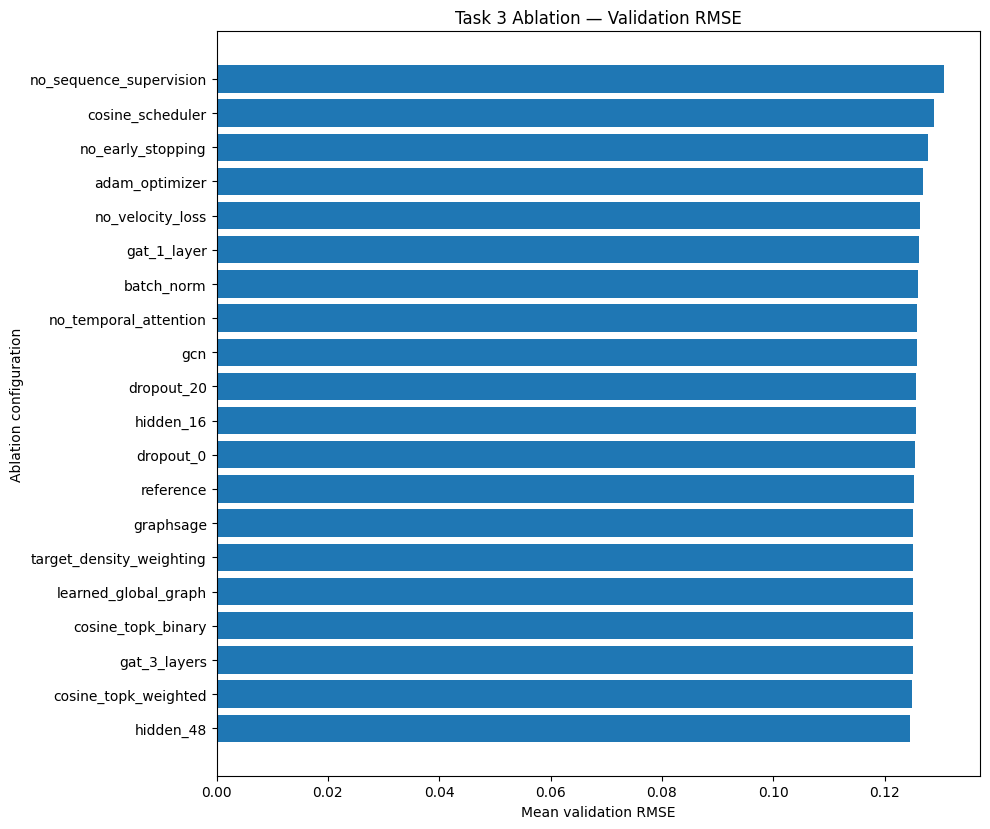

Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/ablation_rmse.png


In [60]:
plot_df = (
    ablation_summary
    .sort_values(
        "mean_rmse",
        ascending=True,
    )
)

plt.figure(
    figsize=(
        10,
        max(
            6,
            0.42
            * len(plot_df),
        ),
    )
)

plt.barh(
    plot_df[
        "config"
    ],
    plot_df[
        "mean_rmse"
    ],
)

plt.xlabel(
    "Mean validation RMSE"
)

plt.ylabel(
    "Ablation configuration"
)

plt.title(
    "Task 3 Ablation — Validation RMSE"
)

plt.tight_layout()

save_path = (
    FIGURE_DIR
    / "ablation_rmse.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    save_path,
)

# Part B — 5-Fold Repetition Cross-Validation

The ablation table above is for model-selection evidence.

For CV, the notebook evaluates **one fixed configuration** against TCN–LSTM.

## Choosing the final CV configuration

By default:

```python
FINAL_CONFIG_NAME = "reference"
```

This uses your established proposed architecture.

If an ablation clearly improves validation performance and you decide to adopt it, change `FINAL_CONFIG_NAME` to that exact configuration name **before running CV**.

For CV we do **not** use each held-out repetition for early stopping. The number of graph-training epochs is fixed from the reference ablation medians.

In [61]:
# ------------------------------------------------------------
# IMPORTANT:
# Freeze this choice before running CV.
# ------------------------------------------------------------
FINAL_CONFIG_NAME = "reference"

FINAL_CONFIG = ABLATION_CONFIGS[
    FINAL_CONFIG_NAME
]

reference_cases = (
    ablation_cases[
        ablation_cases[
            "config"
        ] == "reference"
    ]
)

CV_ADAPTER_EPOCHS = int(
    max(
        1,
        round(
            reference_cases[
                "adapter_epoch"
            ].median()
        ),
    )
)

CV_FINETUNE_EPOCHS = int(
    max(
        0,
        round(
            reference_cases[
                "finetune_epoch"
            ].median()
        ),
    )
)

if QUICK_SMOKE_TEST:
    CV_ADAPTER_EPOCHS = 1
    CV_FINETUNE_EPOCHS = 1

print(
    "CV configuration:",
    FINAL_CONFIG_NAME,
)

print(
    "Fixed CV adapter epochs:",
    CV_ADAPTER_EPOCHS,
)

print(
    "Fixed CV finetune epochs:",
    CV_FINETUNE_EPOCHS,
)

CV configuration: reference
Fixed CV adapter epochs: 18
Fixed CV finetune epochs: 1


## 25. Fixed-epoch proposed-model training for CV

In [62]:
def train_proposed_fixed_epochs(
    model,
    split,
    cfg,
    adapter_epochs,
    finetune_epochs,
    seed,
):
    model, _, _ = train_one_stage(
        model=model,
        split=split,
        cfg=cfg,
        stage="adapter",
        max_epochs=adapter_epochs,
        patience=999999,
        seed=seed,
        use_validation=False,
    )

    model, _, _ = train_one_stage(
        model=model,
        split=split,
        cfg=cfg,
        stage="joint",
        max_epochs=finetune_epochs,
        patience=999999,
        seed=seed + 1,
        use_validation=False,
    )

    return model

## 26. Run 5-fold repetition CV for TCN–LSTM and proposed GNN

In [63]:
def cv_split_for_repetition(
    raw,
    held_out_repetition,
):
    train_repetitions = tuple(
        repetition
        for repetition
        in CV_REPETITIONS
        if repetition
        != held_out_repetition
    )

    return make_scaled_split(
        raw,
        train_repetitions,
        (
            held_out_repetition,
        ),
        (),
    )


cv_rows = []

for fold_index, held_out_rep in enumerate(
    CV_REPETITIONS,
    start=1,
):
    print(
        "\n"
        + "#" * 90
    )

    print(
        f"CV Fold {fold_index}: "
        f"held-out repetition "
        f"{held_out_rep}"
    )

    fold_file = (
        CV_DIR
        / (
            f"fold_{fold_index}_"
            "case_results.csv"
        )
    )

    if fold_file.exists():
        cached = pd.read_csv(
            fold_file
        )

        expected = (
            len(RUN_SUBJECTS)
            * len(RUN_MOVEMENTS)
            * 2
        )

        if len(cached) == expected:
            print(
                "Loading cached fold:",
                fold_file,
            )

            cv_rows.extend(
                cached.to_dict(
                    "records"
                )
            )

            continue

    fold_rows = []

    for subject in RUN_SUBJECTS:
        for movement in RUN_MOVEMENTS:
            movement_name = (
                MOVEMENTS[
                    movement
                ]
            )

            raw = build_all_raw(
                subject,
                movement,
            )

            split = (
                cv_split_for_repetition(
                    raw,
                    held_out_rep,
                )
            )

            case_seed = (
                SEED
                + fold_index * 10000
                + subject * 100
                + movement
            )

            # -----------------------------
            # TCN-LSTM baseline
            # -----------------------------
            reset_seed(
                case_seed
            )

            baseline = (
                TCNLSTMBackbone()
                .to(DEVICE)
            )

            baseline = (
                train_backbone_internal(
                    baseline,
                    split[
                        "B_train"
                    ],
                    split[
                        "y_train"
                    ],
                    RUN_BACKBONE_EPOCHS,
                    case_seed,
                )
            )

            baseline_prediction = (
                predict_backbone(
                    baseline,
                    split["B_val"],
                )
            )

            (
                baseline_rmse,
                baseline_mae,
                baseline_r2,
            ) = regression_metrics(
                split["y_val"],
                baseline_prediction,
            )

            fold_rows.append(
                {
                    "fold": fold_index,
                    "held_out_repetition": (
                        held_out_rep
                    ),
                    "subject": subject,
                    "movement": movement_name,
                    "model": "TCN-LSTM",
                    "rmse": baseline_rmse,
                    "mae": baseline_mae,
                    "r2": baseline_r2,
                }
            )

            # -----------------------------
            # Proposed model
            # Warm-start from SAME baseline
            # -----------------------------
            reset_seed(
                case_seed + 1
            )

            proposed = (
                AblationGATTCNLSTM(
                    FINAL_CONFIG
                )
                .to(DEVICE)
            )

            warm_start_from_backbone(
                proposed,
                baseline,
            )

            proposed = (
                train_proposed_fixed_epochs(
                    model=proposed,
                    split=split,
                    cfg=FINAL_CONFIG,
                    adapter_epochs=(
                        CV_ADAPTER_EPOCHS
                    ),
                    finetune_epochs=(
                        CV_FINETUNE_EPOCHS
                    ),
                    seed=case_seed + 1,
                )
            )

            proposed_prediction = (
                predict_proposed(
                    proposed,
                    split["B_val"],
                    split["N_val"],
                )
            )

            (
                proposed_rmse,
                proposed_mae,
                proposed_r2,
            ) = regression_metrics(
                split["y_val"],
                proposed_prediction,
            )

            fold_rows.append(
                {
                    "fold": fold_index,
                    "held_out_repetition": (
                        held_out_rep
                    ),
                    "subject": subject,
                    "movement": movement_name,
                    "model": (
                        "Proposed GNN"
                    ),
                    "rmse": proposed_rmse,
                    "mae": proposed_mae,
                    "r2": proposed_r2,
                }
            )

            print(
                f"  S{subject} "
                f"{movement_name}: "
                f"baseline RMSE="
                f"{baseline_rmse:.4f}, "
                f"GNN RMSE="
                f"{proposed_rmse:.4f}"
            )

            del (
                baseline,
                proposed,
                raw,
                split,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    fold_df = pd.DataFrame(
        fold_rows
    )

    fold_df.to_csv(
        fold_file,
        index=False,
    )

    cv_rows.extend(
        fold_rows
    )

cv_cases = pd.DataFrame(
    cv_rows
)

cv_cases.to_csv(
    CV_DIR
    / "all_cv_case_results.csv",
    index=False,
)

display(
    cv_cases.head()
)


##########################################################################################
CV Fold 1: held-out repetition 1
  S1 WF: baseline RMSE=0.1355, GNN RMSE=0.1373
  S1 WUD: baseline RMSE=0.1175, GNN RMSE=0.1069
  S1 WECH: baseline RMSE=0.1818, GNN RMSE=0.1621
  S2 WF: baseline RMSE=0.1654, GNN RMSE=0.1717
  S2 WUD: baseline RMSE=0.1986, GNN RMSE=0.1844
  S2 WECH: baseline RMSE=0.0482, GNN RMSE=0.0436
  S3 WF: baseline RMSE=0.1406, GNN RMSE=0.1343
  S3 WUD: baseline RMSE=0.1332, GNN RMSE=0.1317
  S3 WECH: baseline RMSE=0.0928, GNN RMSE=0.0959
  S4 WF: baseline RMSE=0.1437, GNN RMSE=0.1464
  S4 WUD: baseline RMSE=0.1239, GNN RMSE=0.1229
  S4 WECH: baseline RMSE=0.0770, GNN RMSE=0.0826
  S5 WF: baseline RMSE=0.0711, GNN RMSE=0.0672
  S5 WUD: baseline RMSE=0.0701, GNN RMSE=0.0644
  S5 WECH: baseline RMSE=0.0644, GNN RMSE=0.0557
  S6 WF: baseline RMSE=0.3084, GNN RMSE=0.3197
  S6 WUD: baseline RMSE=0.1635, GNN RMSE=0.1653
  S6 WECH: baseline RMSE=0.1933, GNN RMSE=0.1968
  S7 WF: ba

,fold,held_out_repetition,subject,movement,model,rmse,mae,r2
0,1,1,1,WF,TCN-LSTM,0.135459,0.104359,0.542508
1,1,1,1,WF,Proposed GNN,0.137281,0.106980,0.530122
2,1,1,1,WUD,TCN-LSTM,0.117537,0.098297,0.873475
3,1,1,1,WUD,Proposed GNN,0.106858,0.086413,0.895422
4,1,1,1,WECH,TCN-LSTM,0.181848,0.130302,0.385513


## 27. Fold-level metrics: mean ± std

In [64]:
fold_metrics = (
    cv_cases
    .groupby(
        [
            "fold",
            "held_out_repetition",
            "model",
        ],
        as_index=False,
    )
    .agg(
        rmse=(
            "rmse",
            "mean",
        ),
        mae=(
            "mae",
            "mean",
        ),
        r2=(
            "r2",
            "mean",
        ),
    )
)

display(
    fold_metrics.round(6)
)

cv_summary = (
    fold_metrics
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        rmse_mean=(
            "rmse",
            "mean",
        ),
        rmse_std=(
            "rmse",
            "std",
        ),
        mae_mean=(
            "mae",
            "mean",
        ),
        mae_std=(
            "mae",
            "std",
        ),
        r2_mean=(
            "r2",
            "mean",
        ),
        r2_std=(
            "r2",
            "std",
        ),
    )
)

display(
    cv_summary.round(6)
)

cv_summary.to_csv(
    CV_DIR
    / "cv_mean_std_summary.csv",
    index=False,
)

,fold,held_out_repetition,model,rmse,mae,r2
0,1,1,Proposed GNN,0.140943,0.105974,0.586111
1,1,1,TCN-LSTM,0.145038,0.107867,0.572375
2,2,2,Proposed GNN,0.122652,0.091373,0.499157
3,2,2,TCN-LSTM,0.120412,0.090648,0.501600
4,3,3,Proposed GNN,0.109323,0.079484,0.782028
5,3,3,TCN-LSTM,0.106416,0.077398,0.786461
6,4,4,Proposed GNN,0.110224,0.085458,0.735461
7,4,4,TCN-LSTM,0.112913,0.087007,0.724354
8,5,5,Proposed GNN,0.134351,0.099987,0.520461
9,5,5,TCN-LSTM,0.137290,0.101944,0.507391


,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Proposed GNN,0.123499,0.014142,0.092455,0.010699,0.624643,0.127609
1,TCN-LSTM,0.124414,0.016305,0.092973,0.012102,0.618436,0.129956


## 28. Significance test vs TCN–LSTM

In [65]:
baseline_fold = (
    fold_metrics[
        fold_metrics[
            "model"
        ] == "TCN-LSTM"
    ]
    .sort_values(
        "fold"
    )
)

proposed_fold = (
    fold_metrics[
        fold_metrics[
            "model"
        ] == "Proposed GNN"
    ]
    .sort_values(
        "fold"
    )
)

baseline_rmse = (
    baseline_fold[
        "rmse"
    ].to_numpy()
)

proposed_rmse = (
    proposed_fold[
        "rmse"
    ].to_numpy()
)

baseline_r2 = (
    baseline_fold[
        "r2"
    ].to_numpy()
)

proposed_r2 = (
    proposed_fold[
        "r2"
    ].to_numpy()
)

print(
    "Baseline fold RMSE:",
    baseline_rmse,
)

print(
    "Proposed fold RMSE:",
    proposed_rmse,
)

# One-sided paired t-test:
# H1: proposed RMSE < baseline RMSE.
try:
    t_result = ttest_rel(
        proposed_rmse,
        baseline_rmse,
        alternative="less",
    )
except TypeError:
    # Compatibility fallback for older SciPy.
    two_sided = ttest_rel(
        proposed_rmse,
        baseline_rmse,
    )

    t_stat = two_sided.statistic
    two_p = two_sided.pvalue

    if t_stat < 0:
        one_p = two_p / 2
    else:
        one_p = 1 - (
            two_p / 2
        )

    class SimpleResult:
        statistic = t_stat
        pvalue = one_p

    t_result = SimpleResult()

print(
    "\nPaired t-test on RMSE"
)

print(
    "H0: proposed is not lower"
)

print(
    "H1: proposed RMSE is lower"
)

print(
    "t =",
    float(
        t_result.statistic
    ),
)

print(
    "p =",
    float(
        t_result.pvalue
    ),
)

# Wilcoxon signed-rank:
# H1: proposed RMSE < baseline RMSE.
try:
    w_result = wilcoxon(
        proposed_rmse,
        baseline_rmse,
        alternative="less",
        zero_method="wilcox",
    )

    print(
        "\nWilcoxon signed-rank test on RMSE"
    )

    print(
        "W =",
        float(
            w_result.statistic
        ),
    )

    print(
        "p =",
        float(
            w_result.pvalue
        ),
    )

except ValueError as error:
    print(
        "\nWilcoxon could not be computed:",
        error,
    )

alpha = 0.05

if (
    float(
        t_result.pvalue
    )
    < alpha
):
    print(
        "\nPaired t-test conclusion: "
        "significant RMSE improvement "
        "at alpha=0.05."
    )
else:
    print(
        "\nPaired t-test conclusion: "
        "RMSE improvement is not "
        "statistically significant "
        "at alpha=0.05."
    )

Baseline fold RMSE: [0.14503775 0.12041218 0.10641567 0.1129128  0.13729033]
Proposed fold RMSE: [0.1409433  0.12265218 0.10932328 0.11022381 0.13435105]

Paired t-test on RMSE
H0: proposed is not lower
H1: proposed RMSE is lower
t = -0.6320251057442788
p = 0.28084623044234297

Wilcoxon signed-rank test on RMSE
W = 4.0
p = 0.21875

Paired t-test conclusion: RMSE improvement is not statistically significant at alpha=0.05.


## 29. CV comparison figure

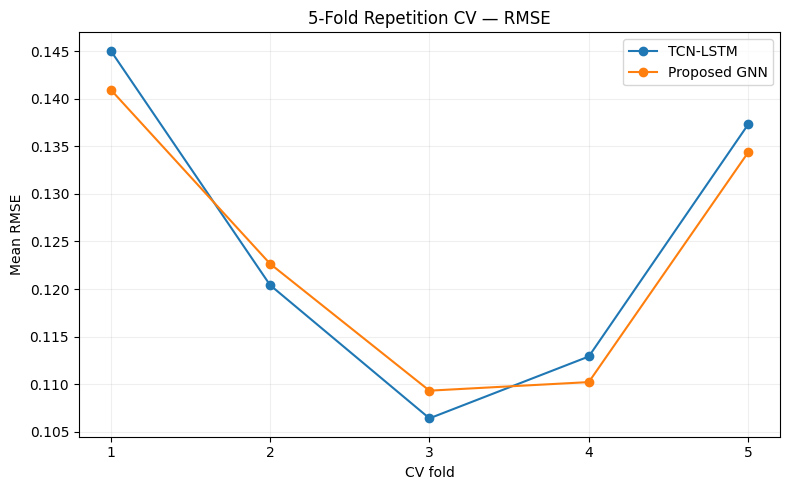

Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/cv_rmse_comparison.png


In [66]:
pivot = (
    fold_metrics
    .pivot(
        index="fold",
        columns="model",
        values="rmse",
    )
    .sort_index()
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    pivot.index,
    pivot["TCN-LSTM"],
    marker="o",
    label="TCN-LSTM",
)

plt.plot(
    pivot.index,
    pivot["Proposed GNN"],
    marker="o",
    label="Proposed GNN",
)

plt.xlabel(
    "CV fold"
)

plt.ylabel(
    "Mean RMSE"
)

plt.title(
    "5-Fold Repetition CV — RMSE"
)

plt.xticks(
    pivot.index
)

plt.legend()
plt.grid(
    alpha=0.2
)

plt.tight_layout()

save_path = (
    FIGURE_DIR
    / "cv_rmse_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    save_path,
)

## 30. Report-ready interpretation template

After running the notebook, use the actual values from `ablation_summary.csv` and `cv_mean_std_summary.csv`.

### Ablation

Write something like:

> The reference Learned Dynamic GAT–TCN–LSTM was systematically ablated while keeping the repetition split and preprocessing fixed. Removing trajectory supervision, changing graph depth/hidden size, replacing learned dynamic adjacency, changing GNN operator, optimization strategy, normalization, and early-stopping policy altered validation performance. The best validation configuration achieved the lowest mean RMSE of **[VALUE]**, compared with **[REFERENCE VALUE]** for the reference configuration.

### 5-fold CV

Write:

> In 5-fold repetition-wise cross-validation over repetitions 1–5, TCN–LSTM achieved RMSE **mean ± std = [VALUE]**, whereas the proposed GNN achieved **[VALUE]**. The paired significance test produced \(p=[VALUE]\).

Do not claim statistical significance unless \(p < 0.05\).

### Regression adaptation of imbalance handling

The original task specification is classification-oriented. Therefore, class-imbalance handling was replaced by **target-density weighting**, where sparsely represented wrist-angle ranges receive larger training weights.

## 31. Files produced

### Ablation

- `ablation/all_ablation_cases.csv`
- `ablation/ablation_summary.csv`
- one CSV for each ablation configuration
- `figures/ablation_rmse.png`

### Cross-validation

- `cv/all_cv_case_results.csv`
- `cv/cv_mean_std_summary.csv`
- one CSV per fold
- `figures/cv_rmse_comparison.png`

These outputs are suitable for the Task 3 report tables and figures.

# Part C — Explainability with SHAP + LIME

The original Task 3 wording says:

> SHAP + LIME for one correct and one wrong sample.

For **regression**, there is no correct/wrong class label. Therefore this notebook uses:

- **Correct / well-predicted sample** = test sample with the **smallest absolute error**.
- **Wrong / poorly-predicted sample** = test sample with the **largest absolute error**.

This is the regression-equivalent interpretation.

## What SHAP and LIME explain

The proposed model has a very high-dimensional sequence input. Explaining thousands of raw scalar values directly would be slow and difficult to interpret.

Instead, SHAP and LIME explain **10 electrode groups**:

```text
E1, E2, ..., E10
```

For electrode `Ei`, the perturbation simultaneously controls:

- its graph-node features;
- its MAV feature;
- its RMS feature.

Thus each explanation answers:

> **How much did each EMG electrode group influence this wrist-angle prediction?**

This is particularly appropriate for the graph model because electrodes are the graph nodes.

### Masking rule

- `1` = keep the electrode information.
- `0` = replace that electrode's standardized inputs with zero, which corresponds approximately to the training mean after standardization.

SHAP measures the change in prediction when electrode groups are enabled relative to a masked baseline.

LIME creates local perturbations around the selected sample and fits a local interpretable surrogate model.

## 32. Install/import SHAP and LIME

In [67]:
import importlib.util
import subprocess
import sys

def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name

    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                pip_name,
            ]
        )

ensure_package("shap")
ensure_package("lime")

import shap
from lime.lime_tabular import LimeTabularExplainer

print("SHAP version:", shap.__version__)
print("SHAP and LIME are ready.")

SHAP version: 0.51.0
SHAP and LIME are ready.


## 33. Explainability case

To keep the notebook practical, SHAP/LIME are demonstrated on one subject × movement test case.

Default:

```text
Subject 1
WECH
```

You can change:

```python
EXPLAIN_SUBJECT
EXPLAIN_MOVEMENT
```

The model is trained on repetitions **1–5** and explanations are selected only from test repetitions **6–10**.

The same final proposed architecture selected for CV is used.

In [68]:
EXPLAIN_SUBJECT = 1
EXPLAIN_MOVEMENT = 17  # 13=WF, 16=WUD, 17=WECH

# Use the same fixed epoch counts selected before CV.
EXPLAIN_ADAPTER_EPOCHS = CV_ADAPTER_EPOCHS
EXPLAIN_FINETUNE_EPOCHS = CV_FINETUNE_EPOCHS

print(
    "Explainability case:",
    f"S{EXPLAIN_SUBJECT}",
    MOVEMENTS[EXPLAIN_MOVEMENT],
)

print(
    "Adapter epochs:",
    EXPLAIN_ADAPTER_EPOCHS,
)

print(
    "Fine-tune epochs:",
    EXPLAIN_FINETUNE_EPOCHS,
)

Explainability case: S1 WECH
Adapter epochs: 18
Fine-tune epochs: 1


## 34. Train/load the final explainability model on repetitions 1–5

In [69]:
EXPLAIN_MODEL_PATH = (
    CV_DIR
    / (
        f"explain_s{EXPLAIN_SUBJECT:02d}_"
        f"m{EXPLAIN_MOVEMENT:02d}_"
        f"{FINAL_CONFIG_NAME}.pt"
    )
)

raw_explain = build_all_raw(
    EXPLAIN_SUBJECT,
    EXPLAIN_MOVEMENT,
)

explain_split = make_scaled_split(
    raw_explain,
    FINAL_TRAIN_REPETITIONS,
    (),
    FINAL_TEST_REPETITIONS,
)

explain_seed = (
    SEED
    + 900000
    + EXPLAIN_SUBJECT * 100
    + EXPLAIN_MOVEMENT
)

explain_baseline = (
    TCNLSTMBackbone()
    .to(DEVICE)
)

explain_model = (
    AblationGATTCNLSTM(
        FINAL_CONFIG
    )
    .to(DEVICE)
)

if EXPLAIN_MODEL_PATH.exists():
    saved = torch.load(
        EXPLAIN_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True,
    )

    explain_model.load_state_dict(
        saved
    )

    print(
        "Loaded explainability model:",
        EXPLAIN_MODEL_PATH,
    )

else:
    reset_seed(
        explain_seed
    )

    explain_baseline = (
        train_backbone_internal(
            explain_baseline,
            explain_split["B_train"],
            explain_split["y_train"],
            RUN_BACKBONE_EPOCHS,
            explain_seed,
        )
    )

    reset_seed(
        explain_seed + 1
    )

    warm_start_from_backbone(
        explain_model,
        explain_baseline,
    )

    explain_model = (
        train_proposed_fixed_epochs(
            model=explain_model,
            split=explain_split,
            cfg=FINAL_CONFIG,
            adapter_epochs=(
                EXPLAIN_ADAPTER_EPOCHS
            ),
            finetune_epochs=(
                EXPLAIN_FINETUNE_EPOCHS
            ),
            seed=explain_seed + 1,
        )
    )

    torch.save(
        explain_model.state_dict(),
        EXPLAIN_MODEL_PATH,
    )

    print(
        "Saved explainability model:",
        EXPLAIN_MODEL_PATH,
    )

explain_model.eval()

Saved explainability model: /kaggle/working/ninapro_db1_task3_ablation/cv/explain_s01_m17_reference.pt


AblationGATTCNLSTM(
  (tcn): TCNEncoder(
    (network): Sequential(
      (0): TemporalBlock(
        (network): Sequential(
          (0): Conv1d(20, 25, kernel_size=(15,), stride=(1,), padding=(14,))
          (1): Chomp1d()
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
          (4): Conv1d(25, 25, kernel_size=(15,), stride=(1,), padding=(14,))
          (5): Chomp1d()
          (6): ReLU()
          (7): Dropout(p=0.2, inplace=False)
        )
        (downsample): Conv1d(20, 25, kernel_size=(1,), stride=(1,))
        (activation): ReLU()
      )
      (1): TemporalBlock(
        (network): Sequential(
          (0): Conv1d(25, 25, kernel_size=(15,), stride=(1,), padding=(28,), dilation=(2,))
          (1): Chomp1d()
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
          (4): Conv1d(25, 25, kernel_size=(15,), stride=(1,), padding=(28,), dilation=(2,))
          (5): Chomp1d()
          (6): ReLU()
          (7): Dropout(p=0.2, inplace=Fals

## 35. Automatically select one well-predicted and one high-error test sample

In [70]:
test_prediction = predict_proposed(
    explain_model,
    explain_split["B_test"],
    explain_split["N_test"],
).reshape(-1)

test_actual = (
    explain_split[
        "y_test"
    ]
    .reshape(-1)
)

absolute_error = np.abs(
    test_prediction
    - test_actual
)

correct_index = int(
    np.argmin(
        absolute_error
    )
)

wrong_index = int(
    np.argmax(
        absolute_error
    )
)

selected_samples = pd.DataFrame(
    [
        {
            "sample_type": (
                "Well-predicted (correct)"
            ),
            "array_index": correct_index,
            "repetition": int(
                explain_split[
                    "rep_test"
                ][correct_index]
            ),
            "target_index": int(
                explain_split[
                    "idx_test"
                ][correct_index]
            ),
            "actual": float(
                test_actual[
                    correct_index
                ]
            ),
            "predicted": float(
                test_prediction[
                    correct_index
                ]
            ),
            "absolute_error": float(
                absolute_error[
                    correct_index
                ]
            ),
        },
        {
            "sample_type": (
                "High-error (wrong)"
            ),
            "array_index": wrong_index,
            "repetition": int(
                explain_split[
                    "rep_test"
                ][wrong_index]
            ),
            "target_index": int(
                explain_split[
                    "idx_test"
                ][wrong_index]
            ),
            "actual": float(
                test_actual[
                    wrong_index
                ]
            ),
            "predicted": float(
                test_prediction[
                    wrong_index
                ]
            ),
            "absolute_error": float(
                absolute_error[
                    wrong_index
                ]
            ),
        },
    ]
)

display(
    selected_samples.round(6)
)

selected_samples.to_csv(
    CV_DIR
    / "explainability_selected_samples.csv",
    index=False,
)

,sample_type,array_index,repetition,target_index,actual,predicted,absolute_error
0,Well-predicted (correct),262,10,142379,0.000000,-0.000285,0.000285
1,High-error (wrong),211,9,141597,-0.148308,0.173359,0.321666


## 36. Electrode-group perturbation wrapper

The explainer receives a 10-dimensional vector:

```text
[E1, E2, ..., E10]
```

For each value:

- `1.0` keeps that electrode;
- `0.0` masks it;
- values between 0 and 1 softly scale the electrode information.

Masking is applied consistently to:

```text
graph input:
nodes[:, :, electrode, :]

manual MAV input:
base[:, :, electrode]

manual RMS input:
base[:, :, 10 + electrode]
```

This means SHAP/LIME explanations correspond to **electrode groups**, rather than individual duplicated representations of the same electrode.

In [71]:
ELECTRODE_NAMES = [
    f"E{i}"
    for i in range(
        1,
        N_EMG + 1,
    )
]


def build_electrode_mask_predictor(
    model,
    base_sample,
    node_sample,
):
    """
    Creates a model function suitable for SHAP/LIME.

    Parameters
    ----------
    base_sample:
        [1, T, 20]

    node_sample:
        [1, T, 10, 14]

    Input to returned predictor:
        masks [M, 10]

    Output:
        prediction [M]
    """

    base_template = np.asarray(
        base_sample,
        dtype=np.float32,
    )

    node_template = np.asarray(
        node_sample,
        dtype=np.float32,
    )

    @torch.no_grad()
    def predictor(mask_matrix):
        masks = np.asarray(
            mask_matrix,
            dtype=np.float32,
        )

        if masks.ndim == 1:
            masks = masks.reshape(
                1,
                -1,
            )

        # LIME can generate values slightly outside
        # the original binary range. Soft clipping
        # keeps the perturbation physically meaningful.
        masks = np.clip(
            masks,
            0.0,
            1.0,
        )

        output = []

        local_batch = 64

        for start in range(
            0,
            len(masks),
            local_batch,
        ):
            batch_masks = masks[
                start:
                start + local_batch
            ]

            batch_size = len(
                batch_masks
            )

            base_batch = np.repeat(
                base_template,
                batch_size,
                axis=0,
            ).copy()

            node_batch = np.repeat(
                node_template,
                batch_size,
                axis=0,
            ).copy()

            # Graph node features
            node_batch *= (
                batch_masks[
                    :,
                    None,
                    :,
                    None,
                ]
            )

            # MAV features, channels 0..9
            base_batch[
                :,
                :,
                :N_EMG,
            ] *= (
                batch_masks[
                    :,
                    None,
                    :,
                ]
            )

            # RMS features, channels 10..19
            base_batch[
                :,
                :,
                N_EMG:
                2 * N_EMG,
            ] *= (
                batch_masks[
                    :,
                    None,
                    :,
                ]
            )

            base_tensor = (
                torch.from_numpy(
                    base_batch
                )
                .float()
                .to(DEVICE)
            )

            node_tensor = (
                torch.from_numpy(
                    node_batch
                )
                .float()
                .to(DEVICE)
            )

            prediction = model(
                base_tensor,
                node_tensor,
            )

            output.append(
                prediction
                .cpu()
                .numpy()
                .reshape(-1)
            )

        return np.concatenate(
            output
        )

    return predictor

## 37. SHAP explanation helper

In [72]:
def explain_with_shap(
    sample_index,
    sample_label,
    nsamples=256,
):
    base_sample = (
        explain_split[
            "B_test"
        ][
            sample_index:
            sample_index + 1
        ]
    )

    node_sample = (
        explain_split[
            "N_test"
        ][
            sample_index:
            sample_index + 1
        ]
    )

    predictor = (
        build_electrode_mask_predictor(
            explain_model,
            base_sample,
            node_sample,
        )
    )

    # Baseline = all electrode groups masked.
    background = np.zeros(
        (
            1,
            N_EMG,
        ),
        dtype=np.float32,
    )

    # Explain the original sample:
    # all electrode groups present.
    instance = np.ones(
        (
            1,
            N_EMG,
        ),
        dtype=np.float32,
    )

    explainer = shap.KernelExplainer(
        predictor,
        background,
    )

    shap_values = explainer.shap_values(
        instance,
        nsamples=nsamples,
        silent=True,
    )

    shap_values = np.asarray(
        shap_values
    )

    # Normalize common SHAP output shapes
    # to one value per electrode.
    shap_values = np.squeeze(
        shap_values
    )

    if shap_values.ndim > 1:
        shap_values = (
            shap_values.reshape(
                -1,
                N_EMG,
            )[0]
        )

    result = pd.DataFrame(
        {
            "electrode": (
                ELECTRODE_NAMES
            ),
            "shap_value": (
                shap_values.astype(
                    float
                )
            ),
            "absolute_shap": (
                np.abs(
                    shap_values
                ).astype(float)
            ),
        }
    ).sort_values(
        "absolute_shap",
        ascending=False,
    )

    display(
        result.round(6)
    )

    csv_path = (
        CV_DIR
        / (
            "shap_"
            + sample_label
            + ".csv"
        )
    )

    result.to_csv(
        csv_path,
        index=False,
    )

    plot_df = (
        result
        .sort_values(
            "shap_value"
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        plot_df[
            "electrode"
        ],
        plot_df[
            "shap_value"
        ],
    )

    plt.axvline(
        0.0,
        linewidth=1,
    )

    plt.xlabel(
        "SHAP contribution to predicted angle"
    )

    plt.ylabel(
        "Electrode group"
    )

    plt.title(
        f"SHAP — {sample_label.replace('_', ' ').title()}"
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            "shap_"
            + sample_label
            + ".png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        csv_path,
    )

    print(
        "Saved:",
        figure_path,
    )

    return result

## 38. Run SHAP for the correct and wrong regression samples

,electrode,shap_value,absolute_shap
1,E2,-0.137547,0.137547
7,E8,-0.127939,0.127939
0,E1,-0.106317,0.106317
6,E7,-0.098037,0.098037
5,E6,-0.064917,0.064917
8,E9,-0.030894,0.030894
9,E10,0.020570,0.020570
4,E5,-0.011820,0.011820
3,E4,0.009144,0.009144
2,E3,-0.000388,0.000388


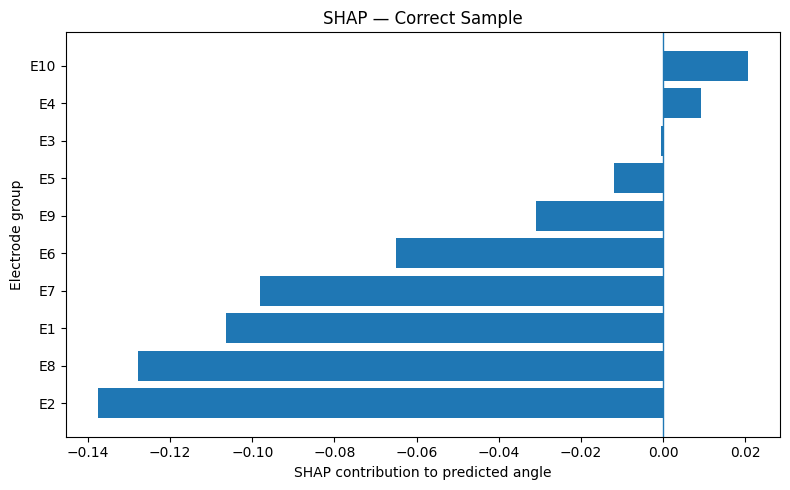

Saved: /kaggle/working/ninapro_db1_task3_ablation/cv/shap_correct_sample.csv
Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/shap_correct_sample.png


,electrode,shap_value,absolute_shap
7,E8,-0.108631,0.108631
0,E1,-0.077101,0.077101
6,E7,-0.052794,0.052794
3,E4,-0.039521,0.039521
2,E3,-0.028750,0.028750
1,E2,-0.028310,0.028310
5,E6,-0.018237,0.018237
9,E10,-0.016514,0.016514
8,E9,-0.006924,0.006924
4,E5,0.002280,0.002280


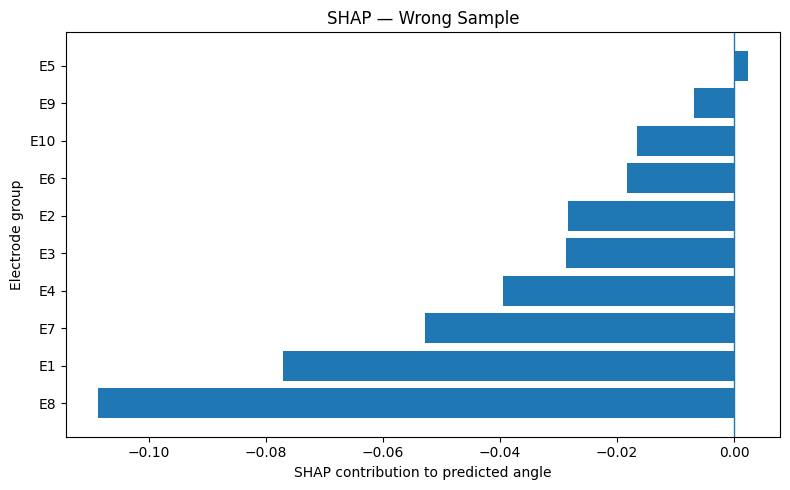

Saved: /kaggle/working/ninapro_db1_task3_ablation/cv/shap_wrong_sample.csv
Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/shap_wrong_sample.png


In [73]:
shap_correct = explain_with_shap(
    correct_index,
    "correct_sample",
    nsamples=256,
)

shap_wrong = explain_with_shap(
    wrong_index,
    "wrong_sample",
    nsamples=256,
)

## 39. LIME explanation helper

In [74]:
def explain_with_lime(
    sample_index,
    sample_label,
    num_samples=1500,
):
    base_sample = (
        explain_split[
            "B_test"
        ][
            sample_index:
            sample_index + 1
        ]
    )

    node_sample = (
        explain_split[
            "N_test"
        ][
            sample_index:
            sample_index + 1
        ]
    )

    predictor = (
        build_electrode_mask_predictor(
            explain_model,
            base_sample,
            node_sample,
        )
    )

    rng = np.random.default_rng(
        SEED
        + sample_index
    )

    # Binary training masks define the interpretable space.
    mask_training_data = rng.integers(
        0,
        2,
        size=(
            512,
            N_EMG,
        ),
    ).astype(
        np.float32
    )

    # Ensure all-masked and all-kept examples exist.
    mask_training_data[0] = 0.0
    mask_training_data[1] = 1.0

    categorical_features = list(
        range(
            N_EMG
        )
    )

    categorical_names = {
        index: [
            "Masked",
            "Kept",
        ]
        for index
        in categorical_features
    }

    lime_explainer = (
        LimeTabularExplainer(
            training_data=(
                mask_training_data
            ),
            feature_names=(
                ELECTRODE_NAMES
            ),
            mode="regression",
            categorical_features=(
                categorical_features
            ),
            categorical_names=(
                categorical_names
            ),
            discretize_continuous=False,
            random_state=SEED,
        )
    )

    instance = np.ones(
        N_EMG,
        dtype=np.float32,
    )

    explanation = (
        lime_explainer
        .explain_instance(
            data_row=instance,
            predict_fn=predictor,
            num_features=N_EMG,
            num_samples=num_samples,
        )
    )

    explanation_list = (
        explanation.as_list()
    )

    result = pd.DataFrame(
        explanation_list,
        columns=[
            "electrode_condition",
            "lime_weight",
        ],
    )

    result[
        "absolute_lime"
    ] = np.abs(
        result[
            "lime_weight"
        ]
    )

    result = result.sort_values(
        "absolute_lime",
        ascending=False,
    )

    display(
        result.round(6)
    )

    csv_path = (
        CV_DIR
        / (
            "lime_"
            + sample_label
            + ".csv"
        )
    )

    result.to_csv(
        csv_path,
        index=False,
    )

    plot_df = (
        result
        .sort_values(
            "lime_weight"
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        plot_df[
            "electrode_condition"
        ],
        plot_df[
            "lime_weight"
        ],
    )

    plt.axvline(
        0.0,
        linewidth=1,
    )

    plt.xlabel(
        "LIME local contribution"
    )

    plt.ylabel(
        "Electrode group"
    )

    plt.title(
        f"LIME — {sample_label.replace('_', ' ').title()}"
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            "lime_"
            + sample_label
            + ".png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        csv_path,
    )

    print(
        "Saved:",
        figure_path,
    )

    return result

## 40. Run LIME for the correct and wrong regression samples

,electrode_condition,lime_weight,absolute_lime
0,E8=Kept,-0.078595,0.078595
1,E1=Kept,-0.056046,0.056046
2,E2=Kept,-0.055594,0.055594
3,E7=Kept,-0.029164,0.029164
4,E6=Kept,-0.029024,0.029024
5,E4=Kept,0.015754,0.015754
6,E3=Kept,0.015031,0.015031
7,E9=Kept,-0.010405,0.010405
8,E5=Kept,-0.002746,0.002746
9,E10=Kept,0.002317,0.002317


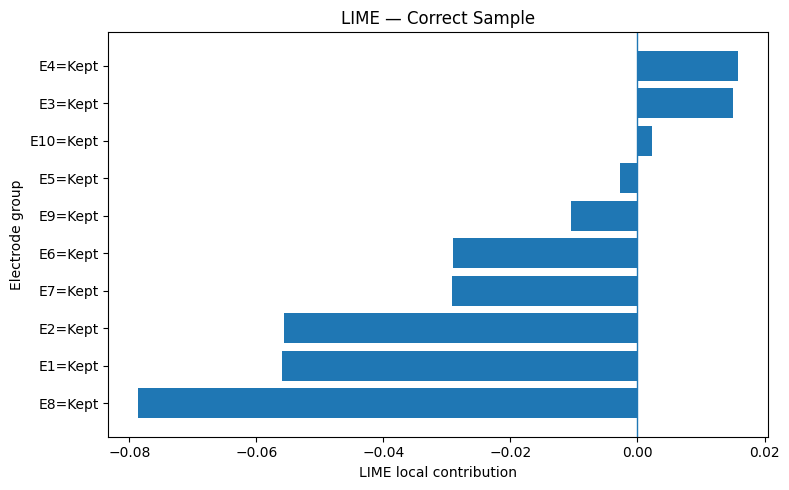

Saved: /kaggle/working/ninapro_db1_task3_ablation/cv/lime_correct_sample.csv
Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/lime_correct_sample.png


,electrode_condition,lime_weight,absolute_lime
0,E8=Kept,-0.062659,0.062659
1,E4=Kept,-0.045477,0.045477
2,E3=Kept,-0.038463,0.038463
3,E1=Kept,-0.026385,0.026385
4,E7=Kept,-0.015673,0.015673
5,E9=Kept,0.007749,0.007749
6,E5=Kept,0.007349,0.007349
7,E2=Kept,0.006946,0.006946
8,E6=Kept,-0.006779,0.006779
9,E10=Kept,-0.004096,0.004096


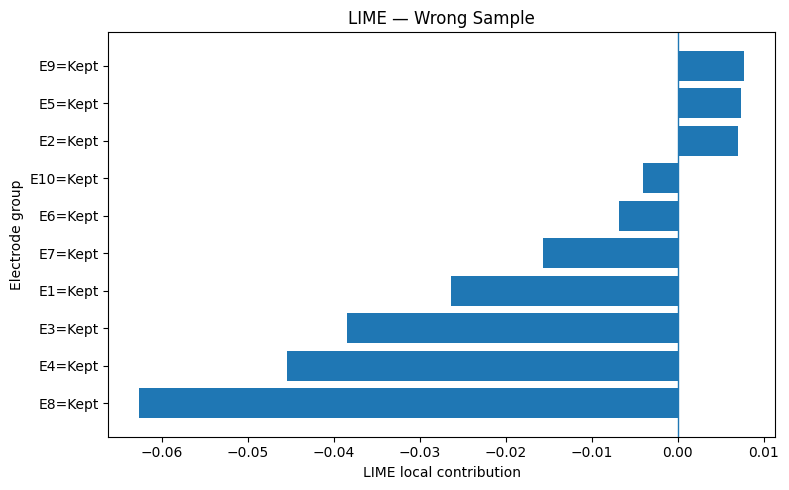

Saved: /kaggle/working/ninapro_db1_task3_ablation/cv/lime_wrong_sample.csv
Saved: /kaggle/working/ninapro_db1_task3_ablation/figures/lime_wrong_sample.png


In [75]:
lime_correct = explain_with_lime(
    correct_index,
    "correct_sample",
    num_samples=1500,
)

lime_wrong = explain_with_lime(
    wrong_index,
    "wrong_sample",
    num_samples=1500,
)

## 41. SHAP + LIME agreement summary

In [76]:
def extract_electrode_name(
    lime_condition,
):
    text = str(
        lime_condition
    )

    for electrode in (
        ELECTRODE_NAMES
    ):
        if electrode in text:
            return electrode

    return text


def explanation_agreement(
    shap_df,
    lime_df,
    sample_type,
):
    shap_rank = (
        shap_df
        .copy()
        .sort_values(
            "absolute_shap",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    shap_rank[
        "shap_rank"
    ] = (
        np.arange(
            1,
            len(shap_rank) + 1,
        )
    )

    lime_rank = (
        lime_df
        .copy()
    )

    lime_rank[
        "electrode"
    ] = (
        lime_rank[
            "electrode_condition"
        ]
        .apply(
            extract_electrode_name
        )
    )

    lime_rank = (
        lime_rank
        .sort_values(
            "absolute_lime",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    lime_rank[
        "lime_rank"
    ] = (
        np.arange(
            1,
            len(lime_rank) + 1,
        )
    )

    merged = pd.merge(
        shap_rank[
            [
                "electrode",
                "shap_value",
                "absolute_shap",
                "shap_rank",
            ]
        ],
        lime_rank[
            [
                "electrode",
                "lime_weight",
                "absolute_lime",
                "lime_rank",
            ]
        ],
        on="electrode",
        how="outer",
    )

    merged[
        "sample_type"
    ] = sample_type

    merged[
        "mean_rank"
    ] = (
        merged[
            [
                "shap_rank",
                "lime_rank",
            ]
        ]
        .mean(
            axis=1
        )
    )

    return merged.sort_values(
        "mean_rank"
    )


agreement_correct = (
    explanation_agreement(
        shap_correct,
        lime_correct,
        "correct",
    )
)

agreement_wrong = (
    explanation_agreement(
        shap_wrong,
        lime_wrong,
        "wrong",
    )
)

agreement = pd.concat(
    [
        agreement_correct,
        agreement_wrong,
    ],
    ignore_index=True,
)

display(
    agreement.round(6)
)

agreement.to_csv(
    CV_DIR
    / "shap_lime_agreement.csv",
    index=False,
)

,electrode,shap_value,absolute_shap,shap_rank,lime_weight,absolute_lime,lime_rank,sample_type,mean_rank
0,E8,-0.127939,0.127939,2,-0.078595,0.078595,1.0,correct,1.5
1,E2,-0.137547,0.137547,1,-0.055594,0.055594,3.0,correct,2.0
2,E1,-0.106317,0.106317,3,-0.056046,0.056046,2.0,correct,2.5
3,E7,-0.098037,0.098037,4,-0.029164,0.029164,4.0,correct,4.0
4,E6,-0.064917,0.064917,5,-0.029024,0.029024,5.0,correct,5.0
5,E1,-0.106317,0.106317,3,0.002317,0.002317,10.0,correct,6.5
6,E10,0.020570,0.020570,7,NaN,NaN,NaN,correct,7.0
7,E9,-0.030894,0.030894,6,-0.010405,0.010405,8.0,correct,7.0
8,E4,0.009144,0.009144,9,0.015754,0.015754,6.0,correct,7.5
9,E3,-0.000388,0.000388,10,0.015031,0.015031,7.0,correct,8.5


## 42. Report-ready SHAP/LIME interpretation

After running the explainability cells, use the actual top-ranked electrodes from the generated CSV files.

### Correct / well-predicted sample

Write:

> For regression, the “correct” example was defined as the test instance with the smallest absolute prediction error. The model predicted **[PREDICTED]** while the true normalized wrist angle was **[ACTUAL]**, producing an absolute error of **[ERROR]**. SHAP identified **[TOP ELECTRODES]** as the strongest electrode-group contributors. LIME produced a similar/different local ranking, with **[TOP ELECTRODES]** having the greatest local influence.

### Wrong / high-error sample

Write:

> The “wrong” regression example was defined as the test instance with the largest absolute error. Its true value was **[ACTUAL]**, whereas the model predicted **[PREDICTED]**. SHAP indicated that **[TOP ELECTRODES]** had the largest contributions, while LIME highlighted **[TOP ELECTRODES]**. The difference between the explanation patterns of the well-predicted and high-error samples suggests that the model may rely on different electrode relationships in difficult regions of the wrist trajectory.

### Important interpretation rule

A positive SHAP/LIME contribution means the electrode tends to **increase the predicted normalized wrist angle relative to the perturbed baseline**.

A negative contribution means it tends to **decrease the prediction**.

Do not interpret a negative value as “unimportant.” Importance is based on the absolute magnitude.

## 43. Complete Task 3 outputs

The corrected notebook now covers:

### Ablation
- layers
- hidden size
- dropout
- normalization / BatchNorm
- LR schedule
- optimizer
- graph construction
- edge weights
- GAT / GCN / GraphSAGE
- target-density weighting
- early stopping
- trajectory-supervision components

### Final comparison
- TCN–LSTM baseline
- proposed GNN
- 5-fold repetition CV
- mean ± std
- paired t-test
- Wilcoxon signed-rank test

### Explainability
- one lowest-error test sample
- one highest-error test sample
- SHAP electrode-group explanation for both
- LIME electrode-group explanation for both
- SHAP/LIME agreement table

### Explainability files
- `cv/explainability_selected_samples.csv`
- `cv/shap_correct_sample.csv`
- `cv/shap_wrong_sample.csv`
- `cv/lime_correct_sample.csv`
- `cv/lime_wrong_sample.csv`
- `cv/shap_lime_agreement.csv`
- `figures/shap_correct_sample.png`
- `figures/shap_wrong_sample.png`
- `figures/lime_correct_sample.png`
- `figures/lime_wrong_sample.png`